# TROPOMI ↔ OCI L1B co-location

Step 1: **time + bounding-box** granule pairing.

**Speed knobs (current):**
1. Only the first `DAY_END` days of July (`DAY_END=7`)
2. Trust **filename times** (no NetCDF open for timing)
3. No `NUM` cap — use every `PACE_STRIDE`-th PACE granule in that window

NetCDF is opened only for **bbox** (PACE geo + TROPOMI chunk geo on time hits).

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from datetime import datetime, timedelta, timezone
from pathlib import Path

import netCDF4 as nc
import numpy as np

# ── config (adjustable) ──────────────────────────────────────────────────────
YEAR, MONTH = 2025, 7
DAY_START = 1          # inclusive
DAY_END = 31            # inclusive — first 7 days of July

PACE_DIR = Path("/home/zhe2/data/PACE/L1B_V3")
# July 2025 BD5 is on kiwi; squid L1/2025 currently ends ~Feb 2025.
TROPOMI_DIR = Path(
    "/kiwi-data/Data/groupMembers/zhe2/MyProjects/TROPOMI_SIF/ESA/L1/2025"
)
TROPOMI_PRODUCT = "OFFL"  # "OFFL" | "RPRO" | "BOTH"

PACE_STRIDE = 1       # every N-th PACE granule
PACE_DURATION_MIN = 5  # filename has start only; approximate end ≈ start + this
DT_MAX_MIN = 60.0      # max |Δt| between granule mid-times (minutes)
BBOX_MARGIN_DEG = 0.5
TROPO_SCAN_STRIDE = 40   # coarser → faster TROPOMI geo reads
TROPO_PIX_STRIDE = 20
TROPO_CHUNK_SCANS = 400

In [2]:
@dataclass(frozen=True)
class TimeWindow:
    path: Path
    start: datetime
    end: datetime
    orbit: int | None = None

    @property
    def mid(self) -> datetime:
        return self.start + (self.end - self.start) / 2


@dataclass(frozen=True)
class BBox:
    lat_min: float
    lat_max: float
    lon_min: float
    lon_max: float  # if lon_min > lon_max, box crosses antimeridian


def expand_bbox(b: BBox, margin: float) -> BBox:
    return BBox(
        lat_min=max(-90.0, b.lat_min - margin),
        lat_max=min(90.0, b.lat_max + margin),
        lon_min=((b.lon_min - margin + 180) % 360) - 180,
        lon_max=((b.lon_max + margin + 180) % 360) - 180,
    )


def lon_intervals_overlap(a0: float, a1: float, b0: float, b1: float) -> bool:
    def parts(lo: float, hi: float) -> list[tuple[float, float]]:
        if lo <= hi:
            return [(lo, hi)]
        return [(lo, 180.0), (-180.0, hi)]

    for x0, x1 in parts(a0, a1):
        for y0, y1 in parts(b0, b1):
            if x0 <= y1 and y0 <= x1:
                return True
    return False


def bboxes_overlap(a: BBox, b: BBox) -> bool:
    if a.lat_max < b.lat_min or b.lat_max < a.lat_min:
        return False
    return lon_intervals_overlap(a.lon_min, a.lon_max, b.lon_min, b.lon_max)


def bbox_from_latlon(lat: np.ndarray, lon: np.ndarray) -> BBox | None:
    m = np.isfinite(lat) & np.isfinite(lon)
    if not m.any():
        return None
    lat_v, lon_v = lat[m], lon[m]
    lon_rad = np.deg2rad(lon_v)
    mean = np.angle(np.mean(np.exp(1j * lon_rad)))
    centered = (lon_rad - mean + np.pi) % (2 * np.pi) - np.pi
    lo = ((np.rad2deg(mean + centered.min()) + 180) % 360) - 180
    hi = ((np.rad2deg(mean + centered.max()) + 180) % 360) - 180
    return BBox(float(lat_v.min()), float(lat_v.max()), float(lo), float(hi))


def time_close(a: TimeWindow, b: TimeWindow, dt_max_min: float) -> bool:
    if a.start <= b.end and b.start <= a.end:
        return True
    return abs((a.mid - b.mid).total_seconds()) / 60.0 <= dt_max_min

In [3]:
# ── discover granules (filename times only) ───────────────────────────────────
PACE_NAME_RE = re.compile(r"PACE_OCI\.(\d{8}T\d{6})\.L1B\.V3\.nc$")
TROPO_NAME_RE = re.compile(
    r"S5P_(OFFL|RPRO)_L1B_RA_BD5_(\d{8}T\d{6})_(\d{8}T\d{6})_(\d+)_.+\.nc$"
)

window_start = datetime(YEAR, MONTH, DAY_START, tzinfo=timezone.utc)
window_end = datetime(YEAR, MONTH, DAY_END, 23, 59, 59, tzinfo=timezone.utc)


def overlaps_window(start: datetime, end: datetime) -> bool:
    return start <= window_end and end >= window_start


def list_pace() -> list[TimeWindow]:
    out: list[TimeWindow] = []
    for p in sorted(PACE_DIR.glob(f"PACE_OCI.{YEAR}{MONTH:02d}*.L1B.V3.nc")):
        m = PACE_NAME_RE.match(p.name)
        if not m:
            continue
        start = datetime.strptime(m.group(1), "%Y%m%dT%H%M%S").replace(
            tzinfo=timezone.utc
        )
        end = start + timedelta(minutes=PACE_DURATION_MIN)
        if overlaps_window(start, end):
            out.append(TimeWindow(p, start, end))
    return out


def list_tropomi() -> list[TimeWindow]:
    out: list[TimeWindow] = []
    for p in sorted(TROPOMI_DIR.rglob("S5P_*_L1B_RA_BD5_*.nc")):
        m = TROPO_NAME_RE.match(p.name)
        if not m:
            continue
        prod, t0, t1, orbit = m.groups()
        if TROPOMI_PRODUCT != "BOTH" and prod != TROPOMI_PRODUCT:
            continue
        start = datetime.strptime(t0, "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
        end = datetime.strptime(t1, "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)
        if overlaps_window(start, end):
            out.append(TimeWindow(p, start, end, orbit=int(orbit)))
    return out


pace_all = list_pace()
tropo_times = list_tropomi()
pace_sub = pace_all[::PACE_STRIDE]  # every N-th; no NUM cap

print(
    f"{YEAR}-{MONTH:02d}-{DAY_START:02d} → {DAY_END:02d}: "
    f"PACE={len(pace_all):,}  (stride={PACE_STRIDE} → {len(pace_sub)})  "
    f"TROPOMI BD5 ({TROPOMI_PRODUCT})={len(tropo_times):,}"
)
if pace_sub:
    print(f"  first PACE: {pace_sub[0].path.name}")
    print(f"  last  PACE: {pace_sub[-1].path.name}")
if tropo_times:
    print(f"  first TROPOMI: {tropo_times[0].path.name}")
    print(f"  last  TROPOMI: {tropo_times[-1].path.name}")

2025-07-01 → 31: PACE=4,511  (stride=1 → 4511)  TROPOMI BD5 (OFFL)=373
  first PACE: PACE_OCI.20250701T000124.L1B.V3.nc
  last  PACE: PACE_OCI.20250731T235940.L1B.V3.nc
  first TROPOMI: S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc
  last  TROPOMI: S5P_OFFL_L1B_RA_BD5_20250731T225436_20250801T003605_40414_03_020101_20250801T022632.nc


In [4]:
# ── bboxes only (times already trusted from filenames) ────────────────────────

def read_pace_bbox(path: Path) -> BBox:
    with nc.Dataset(path) as ds:
        lat = np.asarray(ds["geolocation_data"]["latitude"][:], dtype=float)
        lon = np.asarray(ds["geolocation_data"]["longitude"][:], dtype=float)
    bb = bbox_from_latlon(lat, lon)
    if bb is None:
        raise RuntimeError(f"No valid OCI geolocation in {path.name}")
    return expand_bbox(bb, BBOX_MARGIN_DEG)


def read_tropomi_chunk_bboxes(path: Path) -> list[BBox]:
    """Along-track chunk bboxes (avoids false positives from full-orbit lon span)."""
    with nc.Dataset(path) as ds:
        g = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["GEODATA"]
        lat = np.asarray(
            g["latitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
        )
        lon = np.asarray(
            g["longitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
        )
    chunk = max(1, TROPO_CHUNK_SCANS // TROPO_SCAN_STRIDE)
    boxes: list[BBox] = []
    for i0 in range(0, lat.shape[0], chunk):
        bb = bbox_from_latlon(lat[i0 : i0 + chunk], lon[i0 : i0 + chunk])
        if bb is not None:
            boxes.append(expand_bbox(bb, BBOX_MARGIN_DEG))
    return boxes


print(f"Reading PACE bboxes for {len(pace_sub)} granules …")
pace_meta: list[tuple[TimeWindow, BBox]] = []
for i, tw in enumerate(pace_sub, 1):
    bb = read_pace_bbox(tw.path)
    pace_meta.append((tw, bb))
    if i == 1 or i == len(pace_sub) or i % 20 == 0:
        print(
            f"  [{i}/{len(pace_sub)}] {tw.path.name}: "
            f"{tw.start:%m-%d %H:%M}Z  "
            f"lat[{bb.lat_min:.1f},{bb.lat_max:.1f}] "
            f"lon[{bb.lon_min:.1f},{bb.lon_max:.1f}]"
        )

Reading PACE bboxes for 4511 granules …
  [1/4511] PACE_OCI.20250701T000124.L1B.V3.nc: 07-01 00:01Z  lat[-33.6,-9.6] lon[-177.4,-146.4]
  [20/4511] PACE_OCI.20250701T031305.L1B.V3.nc: 07-01 03:13Z  lat[-51.4,-27.2] lon[135.7,173.7]
  [40/4511] PACE_OCI.20250701T062947.L1B.V3.nc: 07-01 06:29Z  lat[-51.4,-27.2] lon[86.5,124.5]
  [60/4511] PACE_OCI.20250701T094629.L1B.V3.nc: 07-01 09:46Z  lat[-51.4,-27.2] lon[37.3,75.3]
  [80/4511] PACE_OCI.20250701T130310.L1B.V3.nc: 07-01 13:03Z  lat[-51.4,-27.2] lon[-11.9,26.2]
  [100/4511] PACE_OCI.20250701T162452.L1B.V3.nc: 07-01 16:24Z  lat[-33.6,-9.7] lon[-63.3,-32.2]
  [120/4511] PACE_OCI.20250701T194133.L1B.V3.nc: 07-01 19:41Z  lat[-33.7,-9.7] lon[-112.5,-81.4]
  [140/4511] PACE_OCI.20250701T225815.L1B.V3.nc: 07-01 22:58Z  lat[-33.7,-9.7] lon[-161.7,-130.6]
  [160/4511] PACE_OCI.20250702T021457.L1B.V3.nc: 07-02 02:14Z  lat[-33.7,-9.7] lon[149.2,-179.7]
  [180/4511] PACE_OCI.20250702T053138.L1B.V3.nc: 07-02 05:31Z  lat[-33.7,-9.7] lon[100.0,131.1]


In [5]:
# ── time filter (filename), then bbox filter (NetCDF geo) ─────────────────────
tropo_chunk_cache: dict[Path, list[BBox]] = {}

pairs: list[dict] = []
for pace_tw, pace_bb in pace_meta:
    time_hits = [t for t in tropo_times if time_close(pace_tw, t, DT_MAX_MIN)]
    for tropo_tw in time_hits:
        if tropo_tw.path not in tropo_chunk_cache:
            print(f"  TROPOMI geo  orbit={tropo_tw.orbit}  {tropo_tw.path.name}")
            tropo_chunk_cache[tropo_tw.path] = read_tropomi_chunk_bboxes(tropo_tw.path)
        chunks = tropo_chunk_cache[tropo_tw.path]
        if any(bboxes_overlap(pace_bb, c) for c in chunks):
            dt_min = abs((pace_tw.mid - tropo_tw.mid).total_seconds()) / 60.0
            pairs.append(
                {
                    "pace": pace_tw.path.name,
                    "tropomi": tropo_tw.path.name,
                    "orbit": tropo_tw.orbit,
                    "pace_start": pace_tw.start.isoformat(),
                    "tropomi_start": tropo_tw.start.isoformat(),
                    "tropomi_end": tropo_tw.end.isoformat(),
                    "dt_mid_min": round(dt_min, 2),
                    "tropomi_path": str(tropo_tw.path),
                }
            )

print(f"PACE granules tested : {len(pace_meta)}")
print(f"TROPOMI orbits opened: {len(tropo_chunk_cache)}")
print(f"PACE↔TROPOMI pairs   : {len(pairs)}")

  TROPOMI geo  orbit=39989  S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc


/tmp/ipykernel_2198799/911424565.py:15: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(path) as ds:


  TROPOMI geo  orbit=39990  S5P_OFFL_L1B_RA_BD5_20250702T014030_20250702T032200_39990_03_020101_20250702T051259.nc
  TROPOMI geo  orbit=39991  S5P_OFFL_L1B_RA_BD5_20250702T032200_20250702T050330_39991_03_020101_20250702T065259.nc
  TROPOMI geo  orbit=39992  S5P_OFFL_L1B_RA_BD5_20250702T050330_20250702T064500_39992_03_020101_20250702T083312.nc
  TROPOMI geo  orbit=39993  S5P_OFFL_L1B_RA_BD5_20250702T064500_20250702T082630_39993_03_020101_20250702T101326.nc
  TROPOMI geo  orbit=39994  S5P_OFFL_L1B_RA_BD5_20250702T082630_20250702T100800_39994_03_020101_20250702T115331.nc
  TROPOMI geo  orbit=39995  S5P_OFFL_L1B_RA_BD5_20250702T100800_20250702T114930_39995_03_020101_20250702T133344.nc
  TROPOMI geo  orbit=39996  S5P_OFFL_L1B_RA_BD5_20250702T114930_20250702T133059_39996_03_020101_20250702T151355.nc
  TROPOMI geo  orbit=39997  S5P_OFFL_L1B_RA_BD5_20250702T133059_20250702T151229_39997_03_020101_20250702T165434.nc
  TROPOMI geo  orbit=39998  S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_

In [6]:
# ── unique co-located TROPOMI swaths ──────────────────────────────────────────
swaths: dict[str, dict] = {}
for pr in pairs:
    key = pr["tropomi"]
    if key not in swaths:
        swaths[key] = {
            "orbit": pr["orbit"],
            "tropomi": pr["tropomi"],
            "tropomi_start": pr["tropomi_start"],
            "tropomi_end": pr["tropomi_end"],
            "tropomi_path": pr["tropomi_path"],
            "n_pace_matches": 0,
            "pace_granules": [],
        }
    swaths[key]["n_pace_matches"] += 1
    swaths[key]["pace_granules"].append(pr["pace"])

swath_list = sorted(swaths.values(), key=lambda s: (s["tropomi_start"], s["orbit"]))

print(f"Co-located TROPOMI swaths: {len(swath_list)}")
print("=" * 88)
for i, s in enumerate(swath_list, 1):
    print(
        f"{i:3d}. orbit={s['orbit']}  "
        f"{s['tropomi_start'][:19]}Z → {s['tropomi_end'][11:19]}Z  "
        f"PACE matches={s['n_pace_matches']}"
    )
    print(f"     {s['tropomi']}")

colocated_tropomi_swaths = swath_list

Co-located TROPOMI swaths: 373
  1. orbit=39989  2025-07-01T23:59:01Z → 01:40:30Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250701T235901_20250702T014030_39989_03_020101_20250702T032230.nc
  2. orbit=39990  2025-07-02T01:40:30Z → 03:22:00Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T014030_20250702T032200_39990_03_020101_20250702T051259.nc
  3. orbit=39991  2025-07-02T03:22:00Z → 05:03:30Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T032200_20250702T050330_39991_03_020101_20250702T065259.nc
  4. orbit=39992  2025-07-02T05:03:30Z → 06:45:00Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T050330_20250702T064500_39992_03_020101_20250702T083312.nc
  5. orbit=39993  2025-07-02T06:45:00Z → 08:26:30Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T064500_20250702T082630_39993_03_020101_20250702T101326.nc
  6. orbit=39994  2025-07-02T08:26:30Z → 10:08:00Z  PACE matches=10
     S5P_OFFL_L1B_RA_BD5_20250702T082630_20250702T100800_39994_03_020101_20250702T115331.nc
  7. orbi

In [7]:
# to save co-location results as a json file, uncomment the lines
import json

payload = {
    "meta": {
        "created": datetime.now(timezone.utc).isoformat(),
        "description": "TROPOMI BD5 ↔ PACE OCI L1B time+bbox co-location (step 1)",
        "year": YEAR,
        "month": MONTH,
        "day_start": DAY_START,
        "day_end": DAY_END,
        "dt_max_min": DT_MAX_MIN,
        "bbox_margin_deg": BBOX_MARGIN_DEG,
        "pace_dir": str(PACE_DIR),
        "tropomi_dir": str(TROPOMI_DIR),
        "tropomi_product": TROPOMI_PRODUCT,
        "n_swaths": len(swath_list),
    },
    "swaths": swath_list,
}

# with open("co-location_results.json", "w") as f:
#     json.dump(payload, f, indent=2)
#     f.write("\n")


In [8]:
with open("co-location_results_202507.json", "w") as f:
    json.dump(payload, f, indent=2)
    f.write("\n")

# TROPOMI ↔ OCI pixel-wise match-up

Match-up #10
  TROPOMI orbit=39998  S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_39998_03_020101_20250702T184423.nc
  2025-07-02T15:12:29Z → 16:53:59Z
  PACE granules (13):
    PACE_OCI.20250702T151143.L1B.V3.nc
    PACE_OCI.20250702T151643.L1B.V3.nc
    PACE_OCI.20250702T152143.L1B.V3.nc
    PACE_OCI.20250702T152643.L1B.V3.nc
    PACE_OCI.20250702T153143.L1B.V3.nc
    PACE_OCI.20250702T153643.L1B.V3.nc
    PACE_OCI.20250702T154143.L1B.V3.nc
    PACE_OCI.20250702T154643.L1B.V3.nc
    PACE_OCI.20250702T155143.L1B.V3.nc
    PACE_OCI.20250702T155643.L1B.V3.nc
    PACE_OCI.20250702T165004.L1B.V3.nc
    PACE_OCI.20250702T165504.L1B.V3.nc
    PACE_OCI.20250702T170004.L1B.V3.nc
  lat clip |φ|≤70°: kept 319 / 418 scanlines


/tmp/ipykernel_230501/1315855247.py:56: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(path) as ds:


  map central_longitude = -46.9°
  swath quads drawn: 317


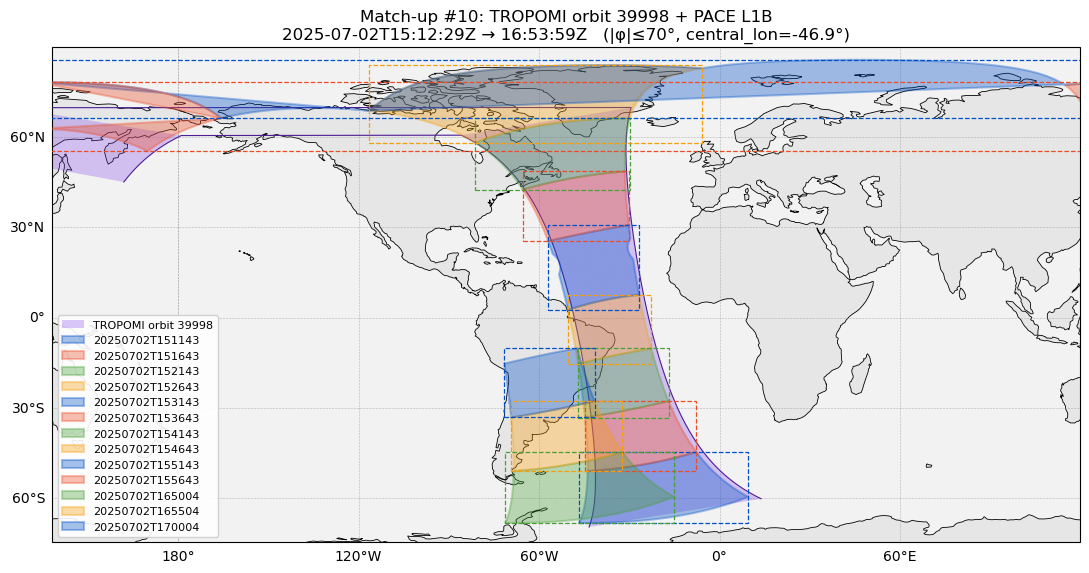

In [7]:
# Plot match-up #N: TROPOMI swath + PACE footprints (antimeridian-safe)
# Uses 1-based index from the printed "Co-located TROPOMI swaths" list.
#
# Swath fill: consecutive scanline quads so left[i]/right[i] stay paired.
# Clip scanlines with |lat| > LAT_CLIP_DEG (default 70°).

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Polygon as MplPolygon

MATCH_ID = 10  # 1-based (as printed); swath_list is 0-based
LAT_CLIP_DEG = 70.0
SCAN_STRIDE = 10

if MATCH_ID < 1 or MATCH_ID > len(swath_list):
    raise IndexError(f"MATCH_ID={MATCH_ID} out of range 1..{len(swath_list)}")

sw = swath_list[MATCH_ID - 1]
tropo_path = Path(sw["tropomi_path"])
pace_names = sw["pace_granules"]
pace_paths = [PACE_DIR / name for name in pace_names]

print(f"Match-up #{MATCH_ID}")
print(f"  TROPOMI orbit={sw['orbit']}  {sw['tropomi']}")
print(f"  {sw['tropomi_start'][:19]}Z → {sw['tropomi_end'][11:19]}Z")
print(f"  PACE granules ({len(pace_paths)}):")
for name in pace_names:
    print(f"    {name}")


# ── helpers ───────────────────────────────────────────────────────────────────

def circular_mean_lon(lon: np.ndarray) -> float:
    lon = np.asarray(lon, dtype=float)
    lon = lon[np.isfinite(lon)]
    if lon.size == 0:
        return 0.0
    return float(np.rad2deg(np.angle(np.mean(np.exp(1j * np.deg2rad(lon))))))


def unwrap_lon(lon: np.ndarray, center: float) -> np.ndarray:
    lon = np.asarray(lon, dtype=float)
    return ((lon - center + 180.0) % 360.0) - 180.0 + center


def align_lon_to_ref(lon: np.ndarray, ref: np.ndarray) -> np.ndarray:
    """Per-point ±360 so each lon lies within ±180° of ref (same shape)."""
    lon = np.asarray(lon, dtype=float)
    ref = np.asarray(ref, dtype=float)
    return lon - 360.0 * np.round((lon - ref) / 360.0)


def tropomi_swath_edges(path: Path, scan_stride: int = SCAN_STRIDE):
    """Return left/right edges; left[i] and right[i] are the same scanline."""
    with nc.Dataset(path) as ds:
        g = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["GEODATA"]
        lat = np.asarray(g["latitude"][0, ::scan_stride, :], dtype=float)
        lon = np.asarray(g["longitude"][0, ::scan_stride, :], dtype=float)
    # ground_pixel 0 and -1 on the *same* scanline index
    return lon[:, 0], lat[:, 0], lon[:, -1], lat[:, -1]


def clip_edges_by_lat(left_lon, left_lat, right_lon, right_lat, lat_max: float):
    """Keep only scanlines where both edges have |lat| ≤ lat_max."""
    left_lon = np.asarray(left_lon, float)
    left_lat = np.asarray(left_lat, float)
    right_lon = np.asarray(right_lon, float)
    right_lat = np.asarray(right_lat, float)
    keep = (
        np.isfinite(left_lat) & np.isfinite(right_lat)
        & np.isfinite(left_lon) & np.isfinite(right_lon)
        & (np.abs(left_lat) <= lat_max)
        & (np.abs(right_lat) <= lat_max)
    )
    n_keep = int(keep.sum())
    print(f"  lat clip |φ|≤{lat_max:g}°: kept {n_keep} / {len(keep)} scanlines")
    if n_keep < 2:
        raise RuntimeError("Too few scanlines after latitude clip")
    return left_lon[keep], left_lat[keep], right_lon[keep], right_lat[keep]


def swath_quads(left_lon, left_lat, right_lon, right_lat, center: float):
    """
    Build one quad per consecutive scanline pair.
    Vertices (same scanline index on left/right):
      i  : left[i], right[i]
      i+1: left[i+1], right[i+1]
    Quad order: left[i] → left[i+1] → right[i+1] → right[i]
    """
    left_lon = np.asarray(left_lon, float)
    right_lon = align_lon_to_ref(np.asarray(right_lon, float), left_lon)
    left_lat = np.asarray(left_lat, float)
    right_lat = np.asarray(right_lat, float)

    # unwrap onto map center for display
    left_lon_c = unwrap_lon(left_lon, center)
    right_lon_c = unwrap_lon(right_lon, center)
    # keep right on same branch as left per scanline after centering
    right_lon_c = align_lon_to_ref(right_lon_c, left_lon_c)

    quads = []
    for i in range(len(left_lon_c) - 1):
        # skip if a scanline step jumps wildly in lon (dateline remnant)
        if abs(left_lon_c[i + 1] - left_lon_c[i]) > 90:
            continue
        if abs(right_lon_c[i + 1] - right_lon_c[i]) > 90:
            continue
        xs = [
            left_lon_c[i], left_lon_c[i + 1],
            right_lon_c[i + 1], right_lon_c[i],
        ]
        ys = [
            left_lat[i], left_lat[i + 1],
            right_lat[i + 1], right_lat[i],
        ]
        quads.append((xs, ys))
    return quads, left_lon_c, left_lat, right_lon_c, right_lat


def pace_corner_ring(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with nc.Dataset(path) as ds:
        lat = np.asarray(ds["geolocation_data"]["latitude"][:], dtype=float)
        lon = np.asarray(ds["geolocation_data"]["longitude"][:], dtype=float)
    top = (lon[0, :], lat[0, :])
    right = (lon[1:, -1], lat[1:, -1])
    bottom = (lon[-1, -2::-1], lat[-1, -2::-1])
    left = (lon[-2:0:-1, 0], lat[-2:0:-1, 0])
    ring_lon = np.concatenate([top[0], right[0], bottom[0], left[0], top[0][:1]])
    ring_lat = np.concatenate([top[1], right[1], bottom[1], left[1], top[1][:1]])
    return ring_lon, ring_lat


def split_ring_jumps(lon: np.ndarray, lat: np.ndarray, jump_deg: float = 180.0):
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    pieces = []
    cur_lon, cur_lat = [lon[0]], [lat[0]]
    for i in range(1, len(lon)):
        if (not np.isfinite(lon[i])) or (not np.isfinite(lat[i])) or (
            abs(lon[i] - lon[i - 1]) > jump_deg
        ):
            if len(cur_lon) >= 3:
                pieces.append((np.asarray(cur_lon), np.asarray(cur_lat)))
            cur_lon, cur_lat = [], []
            if np.isfinite(lon[i]) and np.isfinite(lat[i]):
                cur_lon.append(lon[i])
                cur_lat.append(lat[i])
        else:
            cur_lon.append(lon[i])
            cur_lat.append(lat[i])
    if len(cur_lon) >= 3:
        pieces.append((np.asarray(cur_lon), np.asarray(cur_lat)))
    return pieces


# ── load + clip TROPOMI edges (same scanline index on L/R) ────────────────────
left_lon, left_lat, right_lon, right_lat = tropomi_swath_edges(tropo_path)
left_lon, left_lat, right_lon, right_lat = clip_edges_by_lat(
    left_lon, left_lat, right_lon, right_lat, LAT_CLIP_DEG
)

pace_rings = [pace_corner_ring(pp) for pp in pace_paths]
ref_lon = np.concatenate([r[0] for r in pace_rings]) if pace_rings else left_lon
center = circular_mean_lon(ref_lon)
print(f"  map central_longitude = {center:.1f}°")

quads, left_lon_c, left_lat_c, right_lon_c, right_lat_c = swath_quads(
    left_lon, left_lat, right_lon, right_lat, center
)
print(f"  swath quads drawn: {len(quads)}")

pace_rings_c = [(unwrap_lon(rlon, center), rlat) for rlon, rlat in pace_rings]

all_lon = [left_lon_c, right_lon_c] + [r[0] for r in pace_rings_c]
all_lat = [left_lat_c, right_lat_c] + [r[1] for r in pace_rings_c]
lon0 = float(np.nanmin([np.nanmin(a) for a in all_lon]))
lon1 = float(np.nanmax([np.nanmax(a) for a in all_lon]))
lat0 = float(np.nanmin([np.nanmin(a) for a in all_lat]))
lat1 = float(np.nanmax([np.nanmax(a) for a in all_lat]))
pad = 5.0

proj = ccrs.PlateCarree(central_longitude=center)
pc = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(11, 7), subplot_kw={"projection": proj})
ax.set_extent(
    [lon0 - pad, lon1 + pad, max(-90, lat0 - pad), min(90, lat1 + pad)],
    crs=pc,
)
ax.add_feature(cfeature.LAND, facecolor="0.9", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="0.95", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=1)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", linestyle=":")
gl.top_labels = False
gl.right_labels = False

# TROPOMI swath as same-scanline quads
for j, (xs, ys) in enumerate(quads):
    ax.fill(
        xs, ys,
        transform=pc,
        facecolor="#7C3AED", alpha=0.28, edgecolor="none",
        label=f"TROPOMI orbit {sw['orbit']}" if j == 0 else None,
        zorder=2,
    )
# outline left/right edges
ax.plot(left_lon_c, left_lat_c, transform=pc, color="#4C1D95", lw=0.8, zorder=3)
ax.plot(right_lon_c, right_lat_c, transform=pc, color="#4C1D95", lw=0.8, zorder=3)

colors = ["#0050C7", "#EC4B26", "#47A037", "#F59E0B"]
for i, ((rlon, rlat), name) in enumerate(zip(pace_rings, pace_names)):
    c = colors[i % len(colors)]
    rlon_c = unwrap_lon(rlon, center)
    for j, (plon, plat) in enumerate(split_ring_jumps(rlon_c, rlat)):
        ax.fill(
            plon, plat,
            transform=pc,
            facecolor=c, alpha=0.35, edgecolor=c, linewidth=1.5,
            label=(name.replace("PACE_OCI.", "").replace(".L1B.V3.nc", "") if j == 0 else None),
            zorder=4,
        )
    bb_lon0, bb_lon1 = float(np.nanmin(rlon_c)), float(np.nanmax(rlon_c))
    bb_lat0, bb_lat1 = float(np.nanmin(rlat)), float(np.nanmax(rlat))
    ax.add_patch(
        MplPolygon(
            [
                (bb_lon0, bb_lat0), (bb_lon1, bb_lat0),
                (bb_lon1, bb_lat1), (bb_lon0, bb_lat1),
            ],
            closed=True, fill=False, linestyle="--", linewidth=0.9, edgecolor=c,
            transform=pc, zorder=5,
        )
    )

ax.set_title(
    f"Match-up #{MATCH_ID}: TROPOMI orbit {sw['orbit']} + PACE L1B\n"
    f"{sw['tropomi_start'][:19]}Z → {sw['tropomi_end'][11:19]}Z"
    f"   (|φ|≤{LAT_CLIP_DEG:g}°, central_lon={center:.1f}°)",
    fontsize=12,
)
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()


Match-up #10
TROPOMI : S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_39998_03_020101_20250702T184423.nc
PACE granules: 13
Filters: dist ≤ 2.5 km  AND  |Δt| ≤ 30 min  AND  OCI Lt(λ≥600) < 30
Strides: PACE=150, TROPO scan/pix=2/2


/tmp/ipykernel_909099/2401147407.py:39: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(tropo_path) as ds:


TROPOMI samples: 467,264  (grid (2086, 224))


/tmp/ipykernel_909099/2401147407.py:113: RuntimeWarning: All-NaN slice encountered
  lt_max = np.nanmax(lt, axis=0)  # (nscan_sub, npix_sub)


  [00] PACE_OCI.20250702T151143.L1B.V3.nc: geo=108  dark=42  dist=4  keep=4
  [01] PACE_OCI.20250702T151643.L1B.V3.nc: geo=108  dark=23  dist=4  keep=4
  [02] PACE_OCI.20250702T152143.L1B.V3.nc: geo=108  dark=49  dist=8  keep=8
  [03] PACE_OCI.20250702T152643.L1B.V3.nc: geo=108  dark=39  dist=7  keep=7
  [04] PACE_OCI.20250702T153143.L1B.V3.nc: geo=108  dark=23  dist=4  keep=4
  [05] PACE_OCI.20250702T153643.L1B.V3.nc: geo=108  dark=46  dist=10  keep=10
  [06] PACE_OCI.20250702T154143.L1B.V3.nc: geo=108  dark=3  dist=1  keep=1
  [07] PACE_OCI.20250702T154643.L1B.V3.nc: geo=108  dark=6  dist=2  keep=2
  [08] PACE_OCI.20250702T155143.L1B.V3.nc: geo=108  dark=1  dist=0  keep=0
  [09] PACE_OCI.20250702T155643.L1B.V3.nc: geo=90  dark=37  dist=7  keep=7
  [10] PACE_OCI.20250702T165004.L1B.V3.nc: geo=108  dark=44  dist=0  keep=0


  [11] PACE_OCI.20250702T165504.L1B.V3.nc: geo=108  dark=39  dist=1  keep=0
  [12] PACE_OCI.20250702T170004.L1B.V3.nc: geo=108  dark=1  dist=0  keep=0

PACE geo samples: 1,386  dark (Lt_red<=30): 353  dist hits: 48  kept: 47
Stored pixel_matches n=47  keys=['match_id', 'tropomi_path', 'pace_paths', 'max_dist_km', 'max_dt_min', 'lt_max', 'lt_mask_wl_min', 'pace_stride', 'tropo_scan_stride', 'tropo_pix_stride', 'pace_name', 'pace_file_idx', 'pace_scan', 'pace_pix', 'trop_scan', 'trop_pix', 'pace_lat', 'pace_lon', 'trop_lat', 'trop_lon', 'dist_km', 'dt_min', 'pace_sza', 'pace_vza', 'trop_sza', 'trop_vza']
  dist median=1.93 km  |Δt| median=25.64 min
  PACE  SZA median=42.2°  VZA median=28.6°
  TROPO SZA median=43.6°  VZA median=17.3°


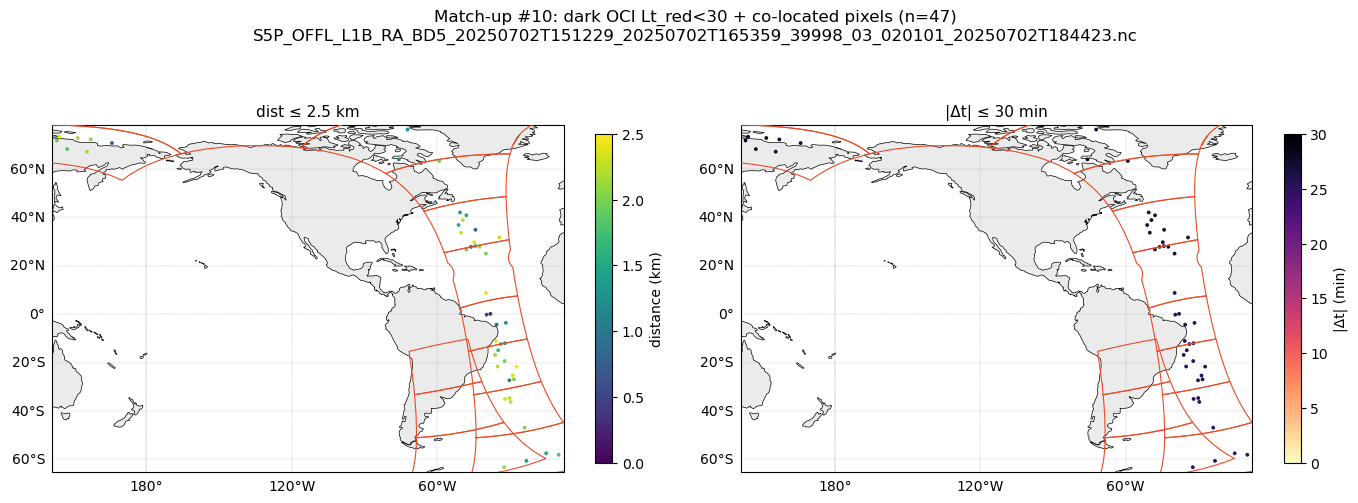

In [10]:
# Pixel-wise match-up for MATCH_ID (from plot cell): all PACE granules × TROPOMI
# Subsample + dist/Δt + OCI Lt_red pre-filter; store matches (incl. SZA/VZA).
#
# OCI dark-pixel mask BEFORE KD-tree (cheap block read of subsampled rhot):
#   keep only if max Lt(λ ≥ LT_MASK_WL_MIN) < LT_MAX
#   Lt = rhot * F0 * cos(SZA) / (π * esd)   [W m^-2 sr^-1 µm^-1]
#
# Timing: each scanline has one time; all pixels in that scan share it.
# Angles: PACE solar/sensor_zenith; TROPOMI solar/viewing_zenith_angle

from scipy.spatial import cKDTree
from netCDF4 import num2date

PACE_STRIDE_PIX = 150      # subsample PACE grid for speed
TROPO_SCAN_STRIDE = 2
TROPO_PIX_STRIDE = 2
MAX_DIST_KM = 2.5          # keep TROPOMI neighbors within this distance
MAX_DT_MIN = 30.0          # |Δt| threshold (minutes); adjustable
LT_MAX = 30.0              # OCI: keep if max Lt(λ ≥ LT_MASK_WL_MIN) < this
LT_MASK_WL_MIN = 600.0     # nm; red and beyond (OCI red CCD)
R_EARTH_KM = 6371.0

print(f"Match-up #{MATCH_ID}")
print(f"TROPOMI : {tropo_path.name}")
print(f"PACE granules: {len(pace_paths)}")
print(
    f"Filters: dist ≤ {MAX_DIST_KM:g} km  AND  |Δt| ≤ {MAX_DT_MIN:g} min  "
    f"AND  OCI Lt(λ≥{LT_MASK_WL_MIN:g}) < {LT_MAX:g}"
)
print(f"Strides: PACE={PACE_STRIDE_PIX}, TROPO scan/pix={TROPO_SCAN_STRIDE}/{TROPO_PIX_STRIDE}")

def lonlat_to_xyz(lon, lat):
    lon_r = np.deg2rad(lon)
    lat_r = np.deg2rad(lat)
    cl = np.cos(lat_r)
    return np.column_stack([cl * np.cos(lon_r), cl * np.sin(lon_r), np.sin(lat_r)])

# ── load TROPOMI once (subsampled) ────────────────────────────────────────────
with nc.Dataset(tropo_path) as ds:
    g = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["GEODATA"]
    obs = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
    trop_lat = np.asarray(
        g["latitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    trop_lon = np.asarray(
        g["longitude"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    trop_sza = np.asarray(
        g["solar_zenith_angle"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    trop_vza = np.asarray(
        g["viewing_zenith_angle"][0, ::TROPO_SCAN_STRIDE, ::TROPO_PIX_STRIDE], dtype=float
    )
    t0 = float(np.asarray(obs["time"][:]).ravel()[0])
    dt_ms = np.asarray(obs["delta_time"][0, :], dtype=float)
    trop_t_units = obs["time"].units

trop_shape = trop_lat.shape
trop_scan_time = np.array(
    num2date(t0 + dt_ms / 1000.0, units=trop_t_units, only_use_cftime_datetimes=False),
    dtype="datetime64[ms]",
)

trop_ok = np.isfinite(trop_lat) & np.isfinite(trop_lon)
trop_flat_i = np.flatnonzero(trop_ok)
trop_xyz = lonlat_to_xyz(trop_lon.ravel()[trop_flat_i], trop_lat.ravel()[trop_flat_i])
tree = cKDTree(trop_xyz)
print(f"TROPOMI samples: {trop_xyz.shape[0]:,}  (grid {trop_shape})")

# ── accumulate matchup pixels over all PACE granules ──────────────────────────
chunks: list[dict] = []
n_pace_geo = 0
n_pace_dark = 0
n_dist_total = 0
n_keep_total = 0

for i_pace, pace_path in enumerate(pace_paths):
    with nc.Dataset(pace_path) as ds:
        geo = ds["geolocation_data"]
        pace_lat = np.asarray(
            geo["latitude"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_lon = np.asarray(
            geo["longitude"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_sza = np.asarray(
            geo["solar_zenith"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_vza = np.asarray(
            geo["sensor_zenith"][::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX], dtype=float
        )
        pace_t_var = ds["scan_line_attributes"]["time"]
        pace_t_all = np.asarray(pace_t_var[:], dtype=float)
        pace_t_units = pace_t_var.units

        # OCI Lt_red pre-filter (subsampled hyperslab — much cheaper than per-match I/O)
        esd = float(getattr(ds, "earth_sun_distance_correction", 1.0))
        wl = np.asarray(ds["sensor_band_parameters"]["red_wavelength"][:], dtype=float)
        f0 = np.asarray(ds["sensor_band_parameters"]["red_solar_irradiance"][:], dtype=float)
        ib = np.flatnonzero(wl >= LT_MASK_WL_MIN)
        if ib.size == 0:
            raise RuntimeError(f"No OCI red bands ≥ {LT_MASK_WL_MIN:g} nm in {pace_path.name}")
        i0, i1 = int(ib[0]), int(ib[-1]) + 1
        rhot = np.asarray(
            ds["observation_data"]["rhot_red"][i0:i1, ::PACE_STRIDE_PIX, ::PACE_STRIDE_PIX],
            dtype=float,
        )  # (nbands, nscan_sub, npix_sub)
        rhot = np.where(rhot > 0, rhot, np.nan)
        f0_b = f0[i0:i1][:, None, None]
        mu0 = np.cos(np.deg2rad(pace_sza))[None, :, :]
        mu0 = np.where(mu0 > 1e-6, mu0, np.nan)
        lt = rhot * f0_b * mu0 / (np.pi * esd)  # W m^-2 sr^-1 µm^-1
        lt_max = np.nanmax(lt, axis=0)  # (nscan_sub, npix_sub)
        dark = np.isfinite(lt_max) & (lt_max < LT_MAX)

    pace_shape = pace_lat.shape
    pace_scan_time = np.array(
        num2date(pace_t_all, units=pace_t_units, only_use_cftime_datetimes=False),
        dtype="datetime64[ms]",
    )

    pace_ok = np.isfinite(pace_lat) & np.isfinite(pace_lon)
    n_geo = int(pace_ok.sum())
    pace_ok &= dark
    n_dark = int(pace_ok.sum())
    n_pace_geo += n_geo
    n_pace_dark += n_dark

    pace_flat_i = np.flatnonzero(pace_ok)
    if pace_flat_i.size == 0:
        print(
            f"  [{i_pace:02d}] {pace_path.name}: "
            f"geo={n_geo:,}  dark={n_dark:,}  — skip (all bright/invalid)"
        )
        continue

    pace_xyz = lonlat_to_xyz(
        pace_lon.ravel()[pace_flat_i], pace_lat.ravel()[pace_flat_i]
    )

    chord, nn = tree.query(pace_xyz, k=1, workers=-1)
    dist_km = 2.0 * R_EARTH_KM * np.arcsin(np.clip(chord / 2.0, 0.0, 1.0))
    close_dist = dist_km <= MAX_DIST_KM

    pace_ji_all = np.unravel_index(pace_flat_i, pace_shape)
    trop_ji_nn = np.unravel_index(trop_flat_i[nn], trop_shape)
    pace_scan_orig = np.clip(
        pace_ji_all[0].astype(np.int64) * PACE_STRIDE_PIX, 0, len(pace_scan_time) - 1
    )
    trop_scan_orig = np.clip(
        trop_ji_nn[0].astype(np.int64) * TROPO_SCAN_STRIDE, 0, len(trop_scan_time) - 1
    )

    dt_min = (
        (trop_scan_time[trop_scan_orig] - pace_scan_time[pace_scan_orig])
        .astype("timedelta64[ms]")
        .astype(np.float64)
        / 60_000.0
    )
    keep = close_dist & (np.abs(dt_min) <= MAX_DT_MIN)

    n_dist = int(close_dist.sum())
    n_keep = int(keep.sum())
    n_dist_total += n_dist
    n_keep_total += n_keep
    print(
        f"  [{i_pace:02d}] {pace_path.name}: "
        f"geo={n_geo:,}  dark={n_dark:,}  dist={n_dist:,}  keep={n_keep:,}"
    )
    if n_keep == 0:
        continue

    pace_ji = np.unravel_index(pace_flat_i[keep], pace_shape)
    trop_ji = np.unravel_index(trop_flat_i[nn[keep]], trop_shape)
    pf = pace_flat_i[keep]
    tf = trop_flat_i[nn[keep]]

    chunks.append(
        {
            "pace_file_idx": np.full(n_keep, i_pace, dtype=np.int16),
            "pace_name": np.full(n_keep, pace_path.name),
            "pace_scan": (pace_ji[0].astype(np.int32) * PACE_STRIDE_PIX),
            "pace_pix": (pace_ji[1].astype(np.int32) * PACE_STRIDE_PIX),
            "trop_scan": (trop_ji[0].astype(np.int32) * TROPO_SCAN_STRIDE),
            "trop_pix": (trop_ji[1].astype(np.int32) * TROPO_PIX_STRIDE),
            "pace_lat": pace_lat.ravel()[pf].astype(np.float32),
            "pace_lon": pace_lon.ravel()[pf].astype(np.float32),
            "trop_lat": trop_lat.ravel()[tf].astype(np.float32),
            "trop_lon": trop_lon.ravel()[tf].astype(np.float32),
            "dist_km": dist_km[keep].astype(np.float32),
            "dt_min": dt_min[keep].astype(np.float32),
            "pace_sza": pace_sza.ravel()[pf].astype(np.float32),
            "pace_vza": pace_vza.ravel()[pf].astype(np.float32),
            "trop_sza": trop_sza.ravel()[tf].astype(np.float32),
            "trop_vza": trop_vza.ravel()[tf].astype(np.float32),
        }
    )

print(
    f"\nPACE geo samples: {n_pace_geo:,}  dark (Lt_red<={LT_MAX:g}): {n_pace_dark:,}  "
    f"dist hits: {n_dist_total:,}  kept: {n_keep_total:,}"
)

if not chunks:
    pixel_matches = None
    print("No matches after dark + dist + Δt filters.")
else:
    keys = [k for k in chunks[0] if k != "pace_name"]
    pixel_matches = {
        "match_id": MATCH_ID,
        "tropomi_path": str(tropo_path),
        "pace_paths": [str(p) for p in pace_paths],
        "max_dist_km": MAX_DIST_KM,
        "max_dt_min": MAX_DT_MIN,
        "lt_max": LT_MAX,
        "lt_mask_wl_min": LT_MASK_WL_MIN,
        "pace_stride": PACE_STRIDE_PIX,
        "tropo_scan_stride": TROPO_SCAN_STRIDE,
        "tropo_pix_stride": TROPO_PIX_STRIDE,
        "pace_name": np.concatenate([c["pace_name"] for c in chunks]),
    }
    for k in keys:
        pixel_matches[k] = np.concatenate([c[k] for c in chunks])

    print(f"Stored pixel_matches n={n_keep_total:,}  keys={list(pixel_matches.keys())}")
    print(
        f"  dist median={np.median(pixel_matches['dist_km']):.2f} km  "
        f"|Δt| median={np.median(np.abs(pixel_matches['dt_min'])):.2f} min"
    )
    print(
        f"  PACE  SZA median={np.nanmedian(pixel_matches['pace_sza']):.1f}°  "
        f"VZA median={np.nanmedian(pixel_matches['pace_vza']):.1f}°"
    )
    print(
        f"  TROPO SZA median={np.nanmedian(pixel_matches['trop_sza']):.1f}°  "
        f"VZA median={np.nanmedian(pixel_matches['trop_vza']):.1f}°"
    )

    # overview map (all granules), colored by distance
    fig, axes = plt.subplots(
        1, 2, figsize=(14, 5.5),
        subplot_kw={"projection": ccrs.PlateCarree(central_longitude=center)},
    )
    pc = ccrs.PlateCarree()
    lon_u = unwrap_lon(pixel_matches["pace_lon"], center)
    plat_u = pixel_matches["pace_lat"]
    extent = [
        float(np.nanmin(lon_u)) - 2, float(np.nanmax(lon_u)) + 2,
        float(np.nanmin(plat_u)) - 2, float(np.nanmax(plat_u)) + 2,
    ]

    ax = axes[0]
    ax.scatter(
        lon_u, plat_u, c=pixel_matches["dist_km"], s=3, cmap="viridis",
        transform=pc, vmin=0, vmax=MAX_DIST_KM, zorder=3,
    )
    for pp in pace_paths:
        rlon, rlat = pace_corner_ring(pp)
        for plon, plat in split_ring_jumps(unwrap_lon(rlon, center), rlat):
            ax.plot(plon, plat, transform=pc, color="#EC4B26", lw=0.8, zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", linestyle=":")
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(
        plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(0, MAX_DIST_KM)),
        ax=ax, shrink=0.7, label="distance (km)",
    )
    ax.set_extent(extent, crs=pc)
    ax.set_title(f"dist ≤ {MAX_DIST_KM:g} km", fontsize=11)

    ax = axes[1]
    abs_dt = np.abs(pixel_matches["dt_min"])
    ax.scatter(
        lon_u, plat_u, c=abs_dt, s=3, cmap="magma_r",
        transform=pc, vmin=0, vmax=MAX_DT_MIN, zorder=3,
    )
    for pp in pace_paths:
        rlon, rlat = pace_corner_ring(pp)
        for plon, plat in split_ring_jumps(unwrap_lon(rlon, center), rlat):
            ax.plot(plon, plat, transform=pc, color="#EC4B26", lw=0.8, zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", linestyle=":")
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(
        plt.cm.ScalarMappable(cmap="magma_r", norm=plt.Normalize(0, MAX_DT_MIN)),
        ax=ax, shrink=0.7, label="|Δt| (min)",
    )
    ax.set_extent(extent, crs=pc)
    ax.set_title(f"|Δt| ≤ {MAX_DT_MIN:g} min", fontsize=11)

    fig.suptitle(
        f"Match-up #{MATCH_ID}: dark OCI Lt_red<{LT_MAX:g} + co-located pixels "
        f"(n={n_keep_total:,})\n{tropo_path.name}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


# Simulating OCI spectra using TROPOMI observations

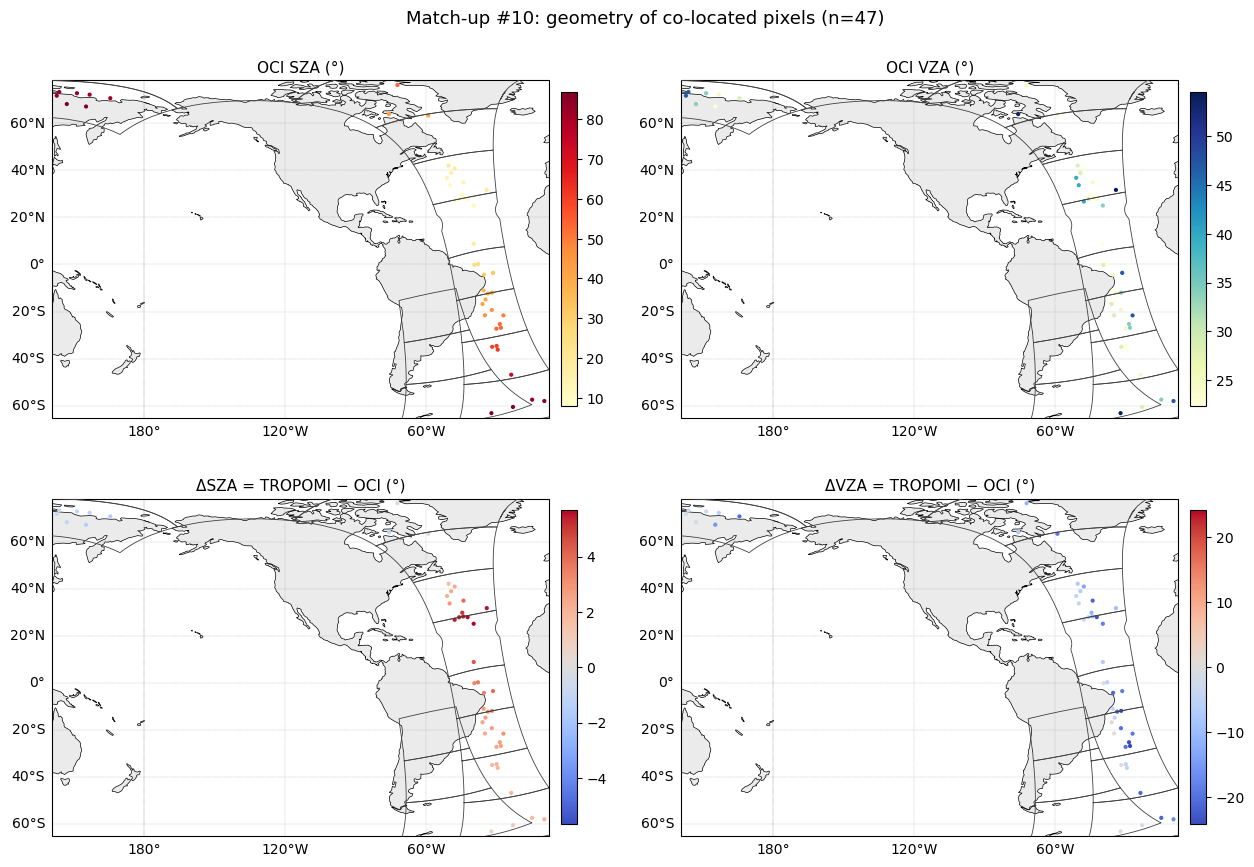

ΔSZA: median=+2.44°  p90|Δ|=5.42°
ΔVZA: median=-7.83°  p90|Δ|=21.49°


In [11]:
# Visualize co-located angles + a few paired spectra
# Requires pixel_matches from the cell above (and plot-cell helpers: center, unwrap_lon, …).

if pixel_matches is None:
    raise RuntimeError("pixel_matches is empty — run the pixel match-up cell first.")
                # number of example spectra to plot
WL_MIN, WL_MAX = 660.0, 720.0  # shared red window for overlay

# ── angle differences (TROPOMI − OCI) ─────────────────────────────────────────
dsza = pixel_matches["trop_sza"] - pixel_matches["pace_sza"]
dvza = pixel_matches["trop_vza"] - pixel_matches["pace_vza"]
lon_u = unwrap_lon(pixel_matches["pace_lon"], center)
lat_u = pixel_matches["pace_lat"]

# ── maps: SZA, VZA, ΔSZA, ΔVZA ────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 2, figsize=(13, 9),
    subplot_kw={"projection": ccrs.PlateCarree(central_longitude=center)},
)
pc = ccrs.PlateCarree()
extent = [
    float(np.nanmin(lon_u)) - 2, float(np.nanmax(lon_u)) + 2,
    float(np.nanmin(lat_u)) - 2, float(np.nanmax(lat_u)) + 2,
]

panels = [
    (pixel_matches["pace_sza"], "OCI SZA (°)", "YlOrRd", False),
    (pixel_matches["pace_vza"], "OCI VZA (°)", "YlGnBu", False),
    (dsza, r"ΔSZA = TROPOMI − OCI (°)", "coolwarm", True),
    (dvza, r"ΔVZA = TROPOMI − OCI (°)", "coolwarm", True),
]

for ax, (vals, title, cmap, diverging) in zip(axes.ravel(), panels):
    if diverging:
        vmax = float(np.nanpercentile(np.abs(vals), 98)) or 1.0
        vmin, vmax = -vmax, vmax
    else:
        vmin = float(np.nanpercentile(vals, 2))
        vmax = float(np.nanpercentile(vals, 98))
    sc = ax.scatter(
        lon_u, lat_u, c=vals, s=4, cmap=cmap,
        transform=pc, vmin=vmin, vmax=vmax, zorder=3,
    )
    for pp in pace_paths:
        rlon, rlat = pace_corner_ring(pp)
        for plon, plat in split_ring_jumps(unwrap_lon(rlon, center), rlat):
            ax.plot(plon, plat, transform=pc, color="0.25", lw=0.6, zorder=4)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=0)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", linestyle=":")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_extent(extent, crs=pc)
    ax.set_title(title, fontsize=11)
    plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)

fig.suptitle(
    f"Match-up #{MATCH_ID}: geometry of co-located pixels (n={len(lon_u):,})",
    fontsize=13,
)
plt.tight_layout()
plt.show()

print(
    f"ΔSZA: median={np.nanmedian(dsza):+.2f}°  "
    f"p90|Δ|={np.nanpercentile(np.abs(dsza), 90):.2f}°"
)
print(
    f"ΔVZA: median={np.nanmedian(dvza):+.2f}°  "
    f"p90|Δ|={np.nanpercentile(np.abs(dvza), 90):.2f}°"
)


Plotting every 10-th tropo_ok match: n=5 / 47 (indices 0…40)
  |ΔVZA|=1.21–24.18°  dist=0.67–2.36 km


/tmp/ipykernel_909099/343015545.py:45: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(pixel_matches["tropomi_path"]) as ds_t:


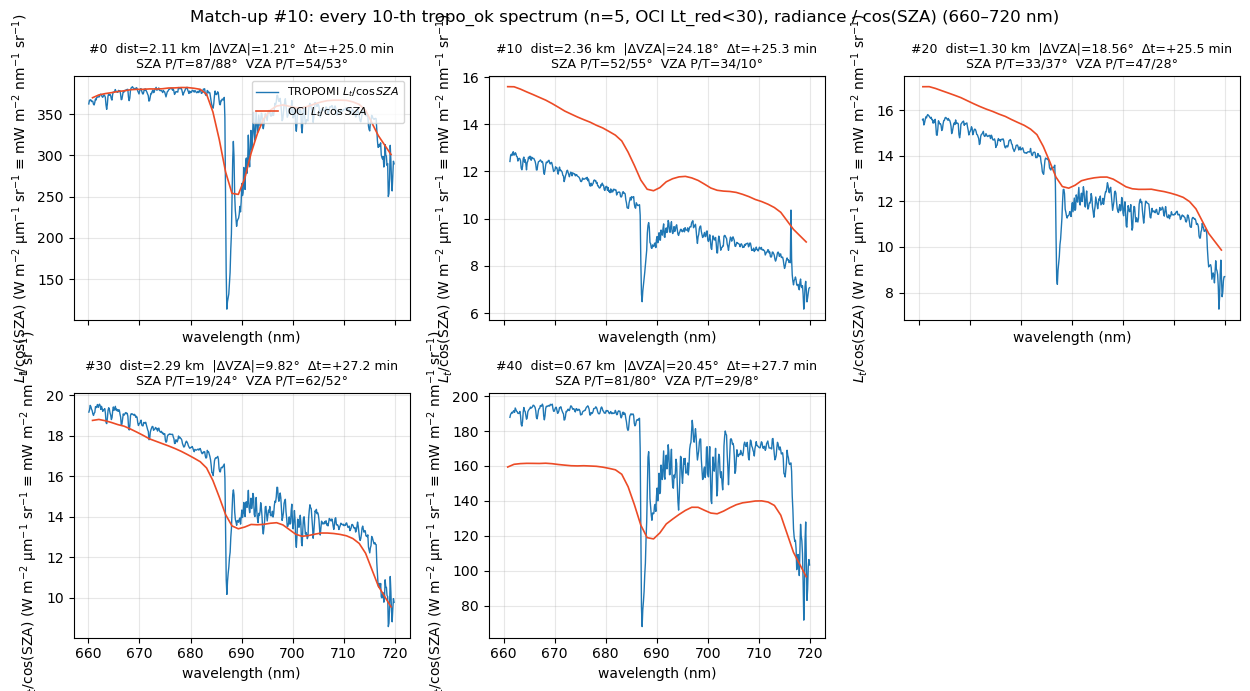

In [12]:
# ── plot every INDEX_STRIDE-th match (finite angles / "ok"); Lt / cos(SZA) ─────
# OCI Lt_red pre-filter already applied when building pixel_matches.
INDEX_STRIDE = 10  # plot cand[0], cand[100], cand[200], …

# same geometric validity used when storing / inspecting matches
tropo_ok = (
    np.isfinite(pixel_matches["pace_sza"])
    & np.isfinite(pixel_matches["trop_sza"])
    & np.isfinite(pixel_matches["pace_vza"])
    & np.isfinite(pixel_matches["trop_vza"])
    & np.isfinite(pixel_matches["dist_km"])
)
cand = np.flatnonzero(tropo_ok)
if cand.size == 0:
    raise RuntimeError("No finite-angle matches to plot spectra.")

pick = cand[::INDEX_STRIDE]
N_SPEC = int(pick.size)
abs_dvza = np.abs(pixel_matches["trop_vza"] - pixel_matches["pace_vza"])
print(
    f"Plotting every {INDEX_STRIDE}-th tropo_ok match: n={N_SPEC} / {cand.size} "
    f"(indices {pick[0]}…{pick[-1]})\n"
    f"  |ΔVZA|={abs_dvza[pick].min():.2f}–{abs_dvza[pick].max():.2f}°  "
    f"dist={pixel_matches['dist_km'][pick].min():.2f}–"
    f"{pixel_matches['dist_km'][pick].max():.2f} km"
)

# Radiance conversions:
#   OCI:     Lt = rhot * F0 * cos(SZA) / (π * esd)   [W m^-2 sr^-1 µm^-1]
#   TROPOMI: mol → mW/m2/sr/nm via (h c Na / λ) * 1e9 * 1e3
# Then rescale each by 1/cos(SZA) of that sensor.
Na = 6.022e23
h = 6.626e-34
c_light = 2.998e8

def tropomi_mol_to_mW(radiance_mol, wavelength_nm):
    """mol s-1 m-2 nm-1 sr-1 → mW m-2 nm-1 sr-1 (OCI_L2_aop factor)."""
    factor = (h * c_light * Na / wavelength_nm) * 1e9 * 1e3
    return radiance_mol * factor

pace_path_by_name = {Path(p).name: Path(p) for p in pixel_matches["pace_paths"]}
pace_cache: dict[str, nc.Dataset] = {}

try:
    with nc.Dataset(pixel_matches["tropomi_path"]) as ds_t:
        inst = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]
        obs = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
        trop_wl_all = np.asarray(inst["nominal_wavelength"][0, :, :], dtype=float)
        trop_rad_var = obs["radiance"]

        ncols = int(np.ceil(N_SPEC / 2))
        fig, axes = plt.subplots(2, max(ncols, 1), figsize=(4.2 * max(ncols, 1), 7), sharex=True)
        axes = np.atleast_1d(axes).ravel()

        for ax, j in zip(axes, pick):
            pname = str(pixel_matches["pace_name"][j])
            pscan = int(pixel_matches["pace_scan"][j])
            ppix = int(pixel_matches["pace_pix"][j])
            tscan = int(pixel_matches["trop_scan"][j])
            tpix = int(pixel_matches["trop_pix"][j])
            sza_p = float(pixel_matches["pace_sza"][j])
            sza_t = float(pixel_matches["trop_sza"][j])

            if pname not in pace_cache:
                pace_cache[pname] = nc.Dataset(pace_path_by_name[pname])
            ds_p = pace_cache[pname]

            esd = float(getattr(ds_p, "earth_sun_distance_correction", 1.0))
            wl_oci = np.asarray(ds_p["sensor_band_parameters"]["red_wavelength"][:], dtype=float)
            f0 = np.asarray(ds_p["sensor_band_parameters"]["red_solar_irradiance"][:], dtype=float)
            rhot = np.asarray(ds_p["observation_data"]["rhot_red"][:, pscan, ppix], dtype=float)
            rhot = np.where(rhot > 0, rhot, np.nan)
            mu0_p = max(float(np.cos(np.deg2rad(sza_p))), 1e-6)
            lt_oci_n = (rhot * f0 * mu0_p / (np.pi * esd)) / mu0_p

            trop_wl = trop_wl_all[tpix]
            trop_mol = np.asarray(trop_rad_var[0, tscan, tpix, :], dtype=float)
            trop_mol = np.where(np.isfinite(trop_mol) & (trop_mol < 1e30), trop_mol, np.nan)
            mu0_t = max(float(np.cos(np.deg2rad(sza_t))), 1e-6)
            lt_trop_n = tropomi_mol_to_mW(trop_mol, trop_wl) / mu0_t

            m_o = (wl_oci >= WL_MIN) & (wl_oci <= WL_MAX) & np.isfinite(lt_oci_n)
            m_t = (trop_wl >= WL_MIN) & (trop_wl <= WL_MAX) & np.isfinite(lt_trop_n)

            ax.plot(trop_wl[m_t], lt_trop_n[m_t], color="#1f77b4", lw=1.0, label=r"TROPOMI $L_t/\cos SZA$")
            ax.plot(wl_oci[m_o], lt_oci_n[m_o], color="#EC4B26", lw=1.2, label=r"OCI $L_t/\cos SZA$")
            ax.set_title(
                f"#{j}  dist={pixel_matches['dist_km'][j]:.2f} km  "
                f"|ΔVZA|={abs_dvza[j]:.2f}°  Δt={pixel_matches['dt_min'][j]:+.1f} min\n"
                f"SZA P/T={pixel_matches['pace_sza'][j]:.0f}/{pixel_matches['trop_sza'][j]:.0f}°  "
                f"VZA P/T={pixel_matches['pace_vza'][j]:.0f}/{pixel_matches['trop_vza'][j]:.0f}°",
                fontsize=9,
            )
            ax.grid(True, alpha=0.3)
            if ax is axes[0]:
                ax.legend(fontsize=8, loc="upper right")

        for ax in axes[N_SPEC:]:
            ax.set_visible(False)
        for ax in axes[:N_SPEC]:
            ax.set_xlabel("wavelength (nm)")
            ax.set_ylabel(
                r"$L_t / \cos(\mathrm{SZA})$ "
                r"(W m$^{-2}$ µm$^{-1}$ sr$^{-1}$ ≡ mW m$^{-2}$ nm$^{-1}$ sr$^{-1}$)"
            )

        lt_tag = pixel_matches.get("lt_max", 30)
        fig.suptitle(
            f"Match-up #{MATCH_ID}: every {INDEX_STRIDE}-th tropo_ok spectrum "
            f"(n={N_SPEC}, OCI Lt_red<{lt_tag:g}), "
            f"radiance / cos(SZA) ({WL_MIN:.0f}–{WL_MAX:.0f} nm)",
            fontsize=12,
        )
        plt.tight_layout()
        plt.show()
finally:
    for ds_p in pace_cache.values():
        ds_p.close()


/tmp/ipykernel_909099/279769218.py:41: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(tropo_path) as ds_t:


TROPOMI file: S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_39998_03_020101_20250702T184423.nc
trop_ok=467,264  SZA<70° & VZA<70° → 310,657  Lt(λ≥660)<30 → 70,852
every 5000-th dark pixel → n=15


/tmp/ipykernel_909099/279769218.py:90: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(tropo_path) as ds_t:


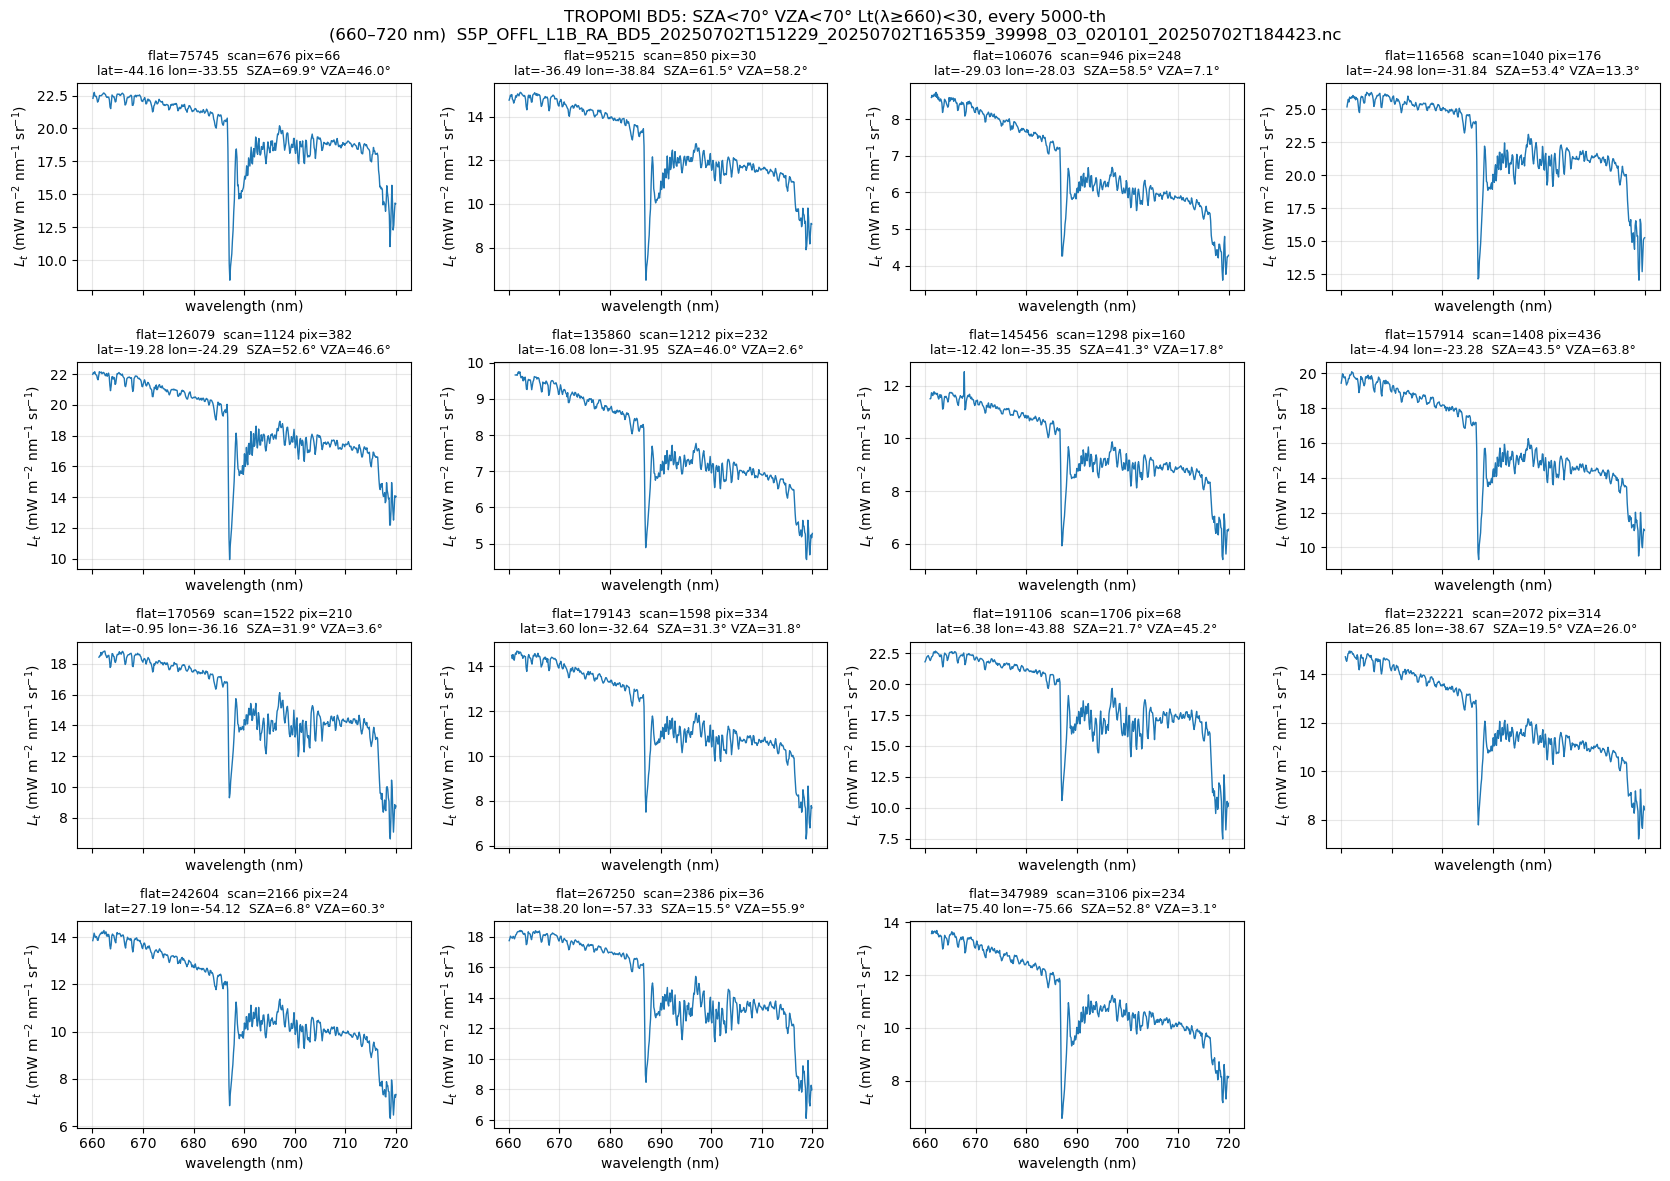

In [13]:
# TROPOMI-only spectra: not from match-ups
# Filter: trop_ok → SZA/VZA cuts → max Lt(λ ≥ LT_MASK_WL_MIN) < LT_MAX → every INDEX_STRIDE-th
# Requires the pixel match-up cell (trop_ok, trop_shape, trop_sza/vza, tropo_path, …).

INDEX_STRIDE = 5000
SZA_MAX_DEG = 70.0
VZA_MAX_DEG = 70.0
LT_MAX = 30.0              # keep if max Lt(λ ≥ LT_MASK_WL_MIN) < this
LT_MASK_WL_MIN = 660.0     # nm; red and beyond (BD5)
WL_MIN_T, WL_MAX_T = 660.0, 720.0
MAX_PLOT = 24  # cap panels if still huge

Na = 6.022e23
h = 6.626e-34
c_light = 2.998e8

def tropomi_mol_to_mW(radiance_mol, wavelength_nm):
    factor = (h * c_light * Na / wavelength_nm) * 1e9 * 1e3
    return radiance_mol * factor

# 1) trop_ok + SZA/VZA
trop_valid_i = np.flatnonzero(trop_ok)
sza_v = trop_sza.ravel()[trop_valid_i]
vza_v = trop_vza.ravel()[trop_valid_i]
ang_ok = (
    np.isfinite(sza_v) & np.isfinite(vza_v)
    & (sza_v < SZA_MAX_DEG) & (vza_v < VZA_MAX_DEG)
)
trop_ang_i = trop_valid_i[ang_ok]
if trop_ang_i.size == 0:
    raise RuntimeError(
        f"No trop_ok pixels with SZA<{SZA_MAX_DEG:g}° and VZA<{VZA_MAX_DEG:g}°."
    )

# 2) Lt_red < LT_MAX (scanline-batched reads)
scan_sub_a, pix_sub_a = np.unravel_index(trop_ang_i, trop_shape)
scan_orig_a = scan_sub_a * TROPO_SCAN_STRIDE
pix_orig_a = pix_sub_a * TROPO_PIX_STRIDE

dark_mask = np.zeros(trop_ang_i.size, dtype=bool)
with nc.Dataset(tropo_path) as ds_t:
    inst = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]
    obs = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
    trop_wl_all = np.asarray(inst["nominal_wavelength"][0, :, :], dtype=float)
    rad = obs["radiance"]

    # band mask per ground pixel (wavelengths vary across track)
    # use mid-swath WL to pick a common channel range, then refine per pixel
    wl_mid = trop_wl_all[trop_wl_all.shape[0] // 2]
    ib = np.flatnonzero((wl_mid >= LT_MASK_WL_MIN) & np.isfinite(wl_mid))
    if ib.size == 0:
        raise RuntimeError(f"No TROPOMI channels ≥ {LT_MASK_WL_MIN:g} nm")
    i0, i1 = int(ib[0]), int(ib[-1]) + 1

    for iscan in np.unique(scan_orig_a):
        sel = scan_orig_a == iscan
        gp_list = pix_orig_a[sel]
        # radiance for this scanline, red+ channels: (n_gp_full, nλ_slice) would be big;
        # only load needed ground pixels
        mol_scan = np.asarray(rad[0, iscan, :, i0:i1], dtype=float)  # (n_gp, nλ)
        mol_scan = np.where(np.isfinite(mol_scan) & (mol_scan < 1e30), mol_scan, np.nan)
        for local_k, gp in zip(np.flatnonzero(sel), gp_list):
            wl = trop_wl_all[gp, i0:i1]
            lt = tropomi_mol_to_mW(mol_scan[gp], wl)
            m = (wl >= LT_MASK_WL_MIN) & np.isfinite(lt)
            if np.any(m) and float(np.nanmax(lt[m])) < LT_MAX:
                dark_mask[local_k] = True

trop_dark_i = trop_ang_i[dark_mask]
print(
    f"TROPOMI file: {Path(tropo_path).name}\n"
    f"trop_ok={int(trop_ok.sum()):,}  "
    f"SZA<{SZA_MAX_DEG:g}° & VZA<{VZA_MAX_DEG:g}° → {trop_ang_i.size:,}  "
    f"Lt(λ≥{LT_MASK_WL_MIN:g})<{LT_MAX:g} → {trop_dark_i.size:,}"
)
if trop_dark_i.size == 0:
    raise RuntimeError(f"No pixels left after Lt < {LT_MAX:g} filter.")

# 3) stride among dark pixels
pick_flat = trop_dark_i[::INDEX_STRIDE]
if pick_flat.size > MAX_PLOT:
    pick_flat = pick_flat[:MAX_PLOT]
    print(f"Capped at MAX_PLOT={MAX_PLOT} spectra (raise to see more).")
print(f"every {INDEX_STRIDE}-th dark pixel → n={pick_flat.size}")

scan_sub, pix_sub = np.unravel_index(pick_flat, trop_shape)
scan_orig = scan_sub * TROPO_SCAN_STRIDE
pix_orig = pix_sub * TROPO_PIX_STRIDE

with nc.Dataset(tropo_path) as ds_t:
    inst = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]
    obs = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
    trop_wl_all = np.asarray(inst["nominal_wavelength"][0, :, :], dtype=float)
    rad = obs["radiance"]
    sza_sub = trop_sza
    vza_sub = trop_vza

    n = pick_flat.size
    ncols = int(np.ceil(n / 4))
    fig, axes = plt.subplots(4, max(ncols, 1), figsize=(4.2 * max(ncols, 1), 12), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, k, iscan, ipix in zip(axes, pick_flat, scan_orig, pix_orig):
        trop_wl = trop_wl_all[ipix]
        mol = np.asarray(rad[0, iscan, ipix, :], dtype=float)
        mol = np.where(np.isfinite(mol) & (mol < 1e30), mol, np.nan)
        lt = tropomi_mol_to_mW(mol, trop_wl)
        ii, jj = np.unravel_index(int(k), trop_shape)

        m = (trop_wl >= WL_MIN_T) & (trop_wl <= WL_MAX_T) & np.isfinite(lt)
        ax.plot(trop_wl[m], lt[m], color="#1f77b4", lw=1.0)
        lat = float(trop_lat[ii, jj])
        lon = float(trop_lon[ii, jj])
        ax.set_title(
            f"flat={k}  scan={iscan} pix={ipix}\n"
            f"lat={lat:.2f} lon={lon:.2f}  "
            f"SZA={sza_sub[ii, jj]:.1f}° VZA={vza_sub[ii, jj]:.1f}°",
            fontsize=9,
        )
        ax.grid(True, alpha=0.3)

    for ax in axes[n:]:
        ax.set_visible(False)
    for ax in axes[:n]:
        ax.set_xlabel("wavelength (nm)")
        ax.set_ylabel(r"$L_t$ (mW m$^{-2}$ nm$^{-1}$ sr$^{-1}$)")

    fig.suptitle(
        f"TROPOMI BD5: SZA<{SZA_MAX_DEG:g}° VZA<{VZA_MAX_DEG:g}° "
        f"Lt(λ≥{LT_MASK_WL_MIN:.0f})<{LT_MAX:g}, every {INDEX_STRIDE}-th\n"
        f"({WL_MIN_T:.0f}–{WL_MAX_T:.0f} nm)  {Path(tropo_path).name}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


## Noise removal

In [14]:
# SVD on TROPOMI spectra at trop_dark_i (after SZA/VZA/Lt filters)
# Wavelengths vary by ground_pixel → interpolate onto a common λ grid, then SVD.
# Stores: trop_svd = {wl, mean, U, s, Vt, n_used, ...}

SVD_WL_MIN, SVD_WL_MAX = 660.0, 720.0
SVD_N_WL = 300              # common wavelength grid size
SVD_MAX_N = 20_000          # subsample trop_dark_i if larger (evenly spaced)
MEAN_CENTER = True          # PCA-style: subtract mean spectrum before SVD

Na = 6.022e23
h = 6.626e-34
c_light = 2.998e8

def tropomi_mol_to_mW(radiance_mol, wavelength_nm):
    return radiance_mol * (h * c_light * Na / wavelength_nm) * 1e9 * 1e3

if "trop_dark_i" not in globals() or trop_dark_i.size == 0:
    raise RuntimeError("Run the TROPOMI filter cell first (needs trop_dark_i).")

# optional evenly spaced subsample for speed/memory
idx_src = trop_dark_i
if idx_src.size > SVD_MAX_N:
    take = np.linspace(0, idx_src.size - 1, SVD_MAX_N, dtype=int)
    idx_src = idx_src[take]
    print(f"Subsampled trop_dark_i → {idx_src.size:,} for SVD (SVD_MAX_N={SVD_MAX_N:,})")
else:
    print(f"Using all trop_dark_i: {idx_src.size:,}")

wl_grid = np.linspace(SVD_WL_MIN, SVD_WL_MAX, SVD_N_WL)
scan_sub, pix_sub = np.unravel_index(idx_src, trop_shape)
scan_orig = scan_sub * TROPO_SCAN_STRIDE
pix_orig = pix_sub * TROPO_PIX_STRIDE

X = np.full((idx_src.size, SVD_N_WL), np.nan, dtype=np.float64)

with nc.Dataset(tropo_path) as ds_t:
    inst = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]
    obs = ds_t["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]
    trop_wl_all = np.asarray(inst["nominal_wavelength"][0, :, :], dtype=float)
    rad = obs["radiance"]

    for iscan in np.unique(scan_orig):
        sel = np.flatnonzero(scan_orig == iscan)
        mol_scan = np.asarray(rad[0, iscan, :, :], dtype=float)  # (gp, λ)
        mol_scan = np.where(np.isfinite(mol_scan) & (mol_scan < 1e30), mol_scan, np.nan)
        for k in sel:
            gp = int(pix_orig[k])
            wl = trop_wl_all[gp]
            lt = tropomi_mol_to_mW(mol_scan[gp], wl)
            m = np.isfinite(wl) & np.isfinite(lt)
            if m.sum() < 10:
                continue
            order = np.argsort(wl[m])
            X[k] = np.interp(wl_grid, wl[m][order], lt[m][order], left=np.nan, right=np.nan)

row_ok = np.isfinite(X).all(axis=1)
X = X[row_ok]
svd_idx = idx_src[row_ok]
print(f"Finite spectra for SVD: {X.shape[0]:,} × {X.shape[1]} bands")
if X.shape[0] < 10:
    raise RuntimeError("Too few complete spectra for SVD.")

mean_spec = X.mean(axis=0) if MEAN_CENTER else np.zeros(SVD_N_WL)
Xc = X - mean_spec

# economy SVD: Xc ≈ U @ diag(s) @ Vt
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
var_frac = (s ** 2) / (s ** 2).sum()

trop_svd = {
    "wl": wl_grid,
    "mean": mean_spec,
    "U": U,
    "s": s,
    "Vt": Vt,  # rows = spectral PCs (unit vectors)
    "var_frac": var_frac,
    "X": X,
    "idx": svd_idx,
    "mean_center": MEAN_CENTER,
    "wl_min": SVD_WL_MIN,
    "wl_max": SVD_WL_MAX,
    "tropomi_path": str(tropo_path),
}
print(
    f"SVD done: rank={s.size}, "
    f"var in PC1–10 = {100 * var_frac[:10].sum():.2f}%, "
    f"PC1 alone = {100 * var_frac[0]:.2f}%"
)


Subsampled trop_dark_i → 20,000 for SVD (SVD_MAX_N=20,000)


/tmp/ipykernel_909099/950709714.py:36: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(tropo_path) as ds_t:


Finite spectra for SVD: 6,328 × 300 bands
SVD done: rank=300, var in PC1–10 = 99.99%, PC1 alone = 98.53%


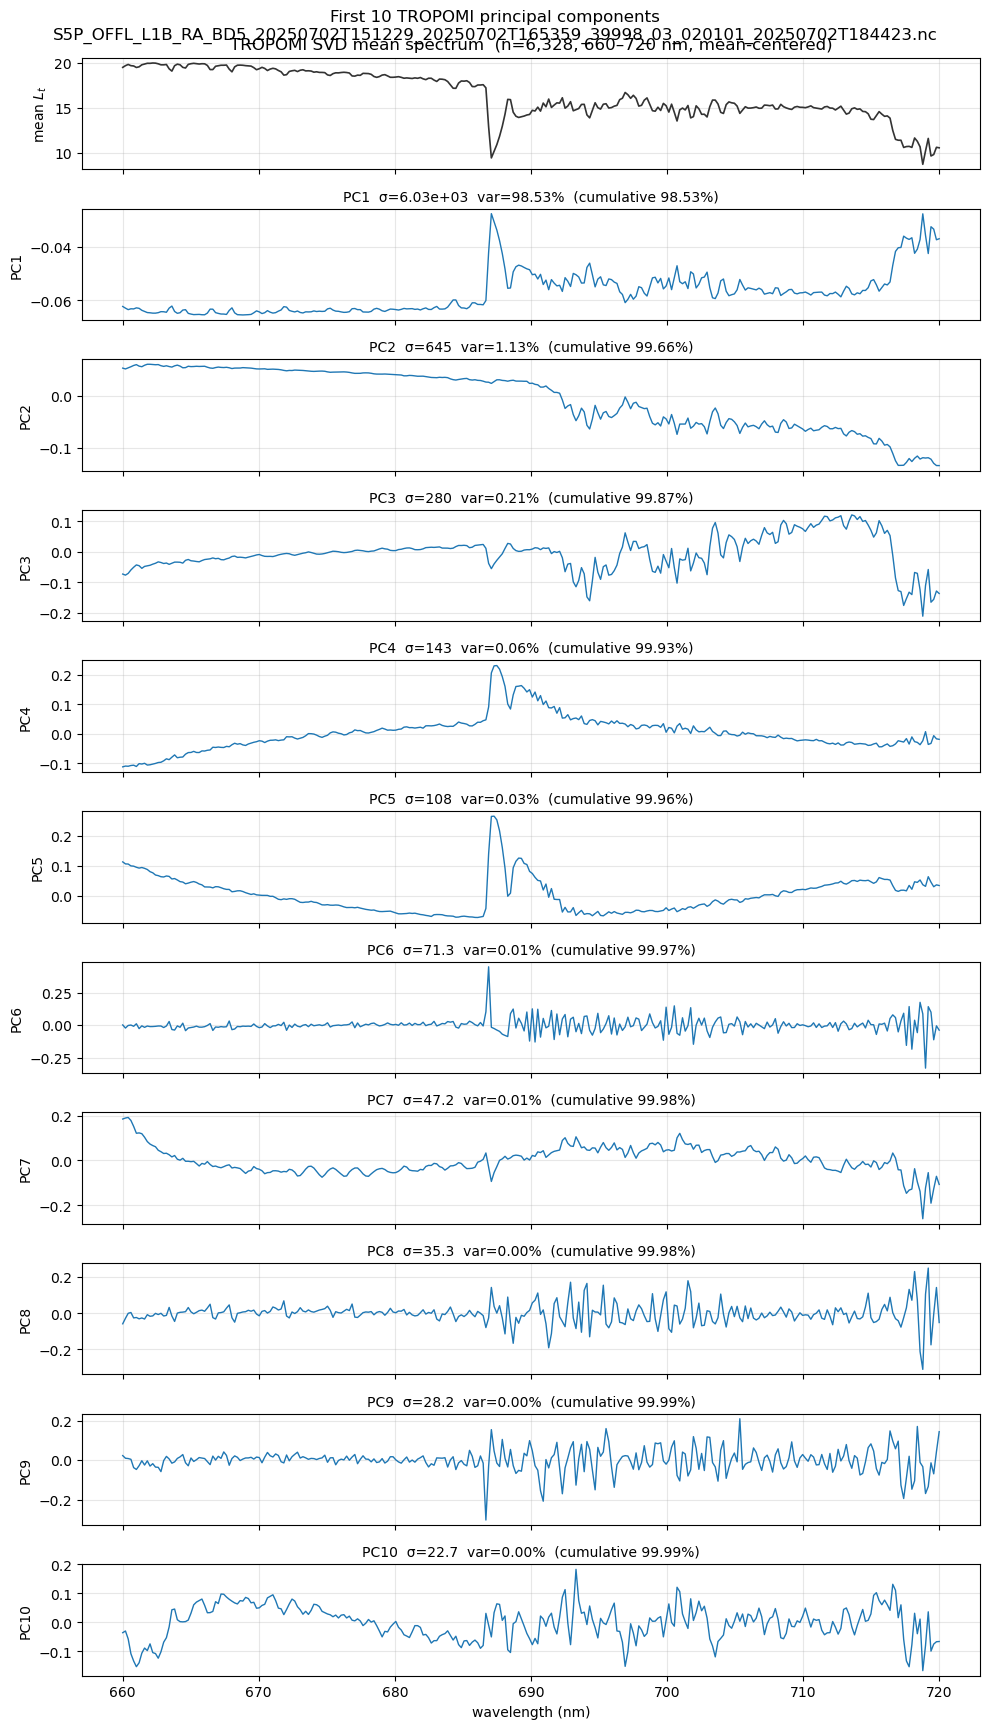

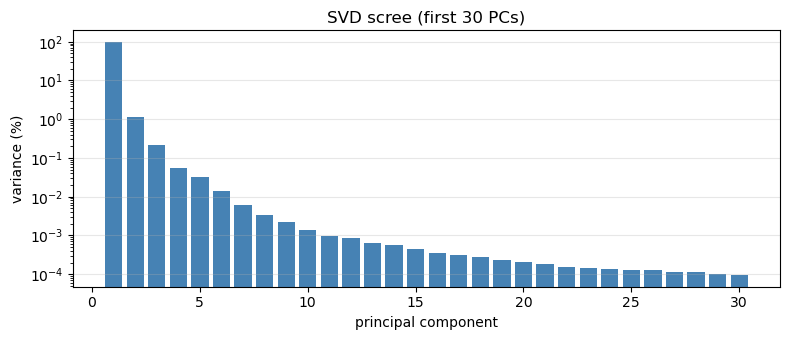

In [15]:
# Plot the first N_PC spectral principal components from trop_svd
N_PC = 10

if "trop_svd" not in globals():
    raise RuntimeError("Run the SVD cell first (needs trop_svd).")

wl = trop_svd["wl"]
Vt = trop_svd["Vt"]
s = trop_svd["s"]
var_frac = trop_svd["var_frac"]
mean_spec = trop_svd["mean"]
N_PC = min(N_PC, Vt.shape[0])

fig, axes = plt.subplots(N_PC + 1, 1, figsize=(10, 1.6 * (N_PC + 1)), sharex=True)

# mean spectrum
ax = axes[0]
ax.plot(wl, mean_spec, color="0.2", lw=1.2)
ax.set_ylabel("mean $L_t$")
ax.set_title(
    f"TROPOMI SVD mean spectrum  (n={trop_svd['X'].shape[0]:,}, "
    f"{trop_svd['wl_min']:.0f}–{trop_svd['wl_max']:.0f} nm"
    + (", mean-centered)" if trop_svd["mean_center"] else ")")
)
ax.grid(True, alpha=0.3)

for i in range(N_PC):
    ax = axes[i + 1]
    ax.plot(wl, Vt[i], color="C0", lw=1.0)
    ax.set_ylabel(f"PC{i+1}")
    ax.set_title(
        f"PC{i+1}  σ={s[i]:.3g}  var={100*var_frac[i]:.2f}%  "
        f"(cumulative {100*var_frac[:i+1].sum():.2f}%)",
        fontsize=10,
    )
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("wavelength (nm)")
fig.suptitle(
    f"First {N_PC} TROPOMI principal components\n{Path(trop_svd['tropomi_path']).name}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# scree plot
fig, ax = plt.subplots(figsize=(8, 3.5))
k = min(30, var_frac.size)
ax.bar(np.arange(1, k + 1), 100 * var_frac[:k], color="steelblue", edgecolor="none")
ax.set_yscale("log")
ax.set_xlabel("principal component")
ax.set_ylabel("variance (%)")
ax.set_title("SVD scree (first 30 PCs)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


Resynthesized with N_PC=10  (explained var=99.99%)
  residual RMSE: median=0.04139  p90=0.06503  mean=0.04545


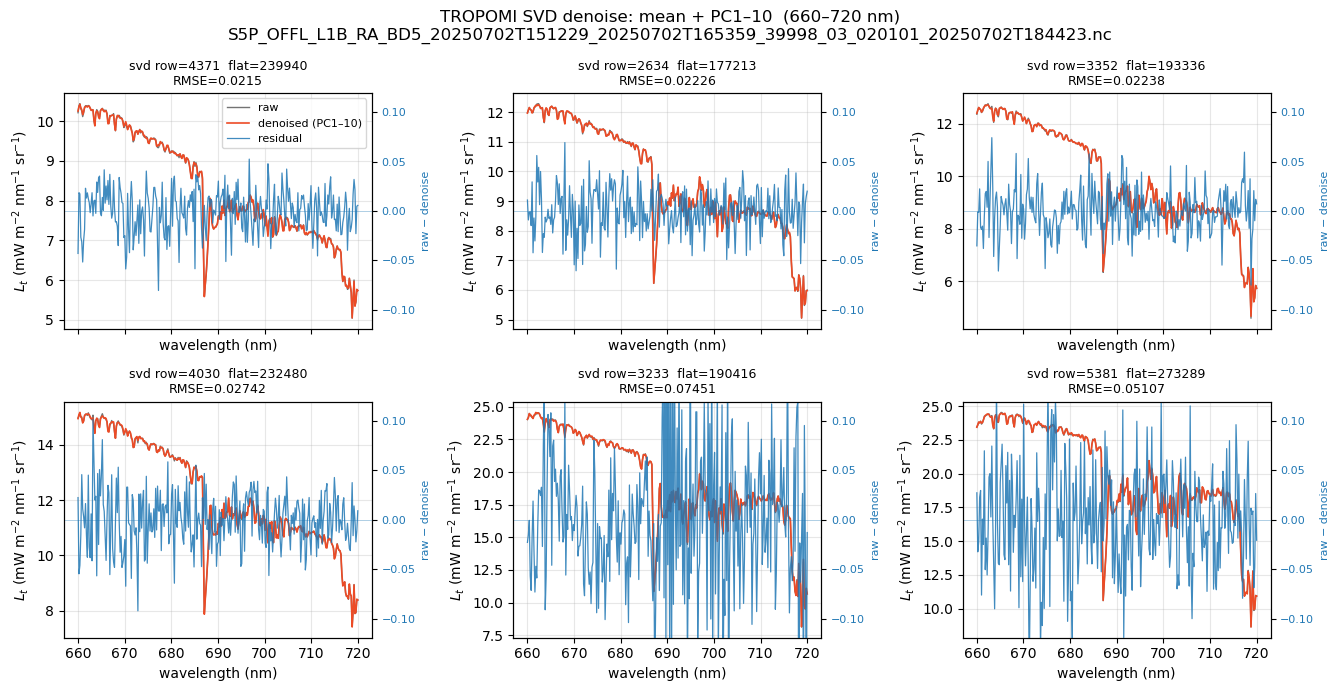

In [ ]:
# Resynthesize / denoise TROPOMI spectra with mean + first N_PC principal components
# X_hat = mean + U[:, :N_PC] @ diag(s[:N_PC]) @ Vt[:N_PC, :]

N_PC = 10
N_SHOW = 6         # sample overlays to plot
SHOW_SEED = 0       # for reproducible random sample indices

if "trop_svd" not in globals():
    raise RuntimeError("Run the SVD cell first (needs trop_svd).")

wl = trop_svd["wl"]
X = trop_svd["X"]
U = trop_svd["U"]
s = trop_svd["s"]
Vt = trop_svd["Vt"]
mean_spec = trop_svd["mean"]
N_PC = min(N_PC, s.size)

# low-rank reconstruction in the (mean-centered) SVD basis
X_hat = mean_spec + (U[:, :N_PC] * s[:N_PC]) @ Vt[:N_PC, :]
resid = X - X_hat
rmse = np.sqrt(np.nanmean(resid ** 2, axis=1))

trop_svd["N_PC_recon"] = N_PC
trop_svd["X_hat"] = X_hat
trop_svd["rmse"] = rmse

print(
    f"Resynthesized with N_PC={N_PC}  "
    f"(explained var={100 * trop_svd['var_frac'][:N_PC].sum():.2f}%)\n"
    f"  residual RMSE: median={np.median(rmse):.4g}  "
    f"p90={np.percentile(rmse, 90):.4g}  mean={rmse.mean():.4g}"
)

# sample spectra to display
rng = np.random.default_rng(SHOW_SEED)
n = X.shape[0]
N_SHOW = min(N_SHOW, n)
# mix of lowest and random RMSE so we see both easy and typical cases
n_best = max(1, N_SHOW // 2)
best = np.argsort(rmse)[:n_best]
rest = np.setdiff1d(np.arange(n), best)
rand = rng.choice(rest, size=N_SHOW - n_best, replace=False) if rest.size else np.array([], dtype=int)
pick = np.concatenate([best, rand])

ncols = int(np.ceil(N_SHOW / 2))
fig, axes = plt.subplots(2, ncols, figsize=(4.5 * ncols, 7), sharex=True)
axes = np.atleast_1d(axes).ravel()

# shared residual y-lims across panels for comparable twin axes
resid_pick = resid[pick]
rmax = float(np.nanpercentile(np.abs(resid_pick), 98)) or 1.0

for ax, j in zip(axes, pick):
    ax.plot(wl, X[j], color="0.45", lw=1.0, label="raw")
    ax.plot(wl, X_hat[j], color="#EC4B26", lw=1.2, label=fr"denoised (PC1–{N_PC})")
    flat_i = int(trop_svd["idx"][j])
    ax.set_title(
        f"svd row={j}  flat={flat_i}\nRMSE={rmse[j]:.4g}",
        fontsize=9,
    )
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(wl, resid[j], color="#1f77b4", lw=0.9, alpha=0.85, label="residual")
    ax2.axhline(0.0, color="#1f77b4", lw=0.5, alpha=0.5)
    ax2.set_ylim(-rmax, rmax)
    ax2.set_ylabel(r"raw − denoise", color="#1f77b4", fontsize=8)
    ax2.tick_params(axis="y", labelcolor="#1f77b4", labelsize=8)

    if ax is axes[0]:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper right")

for ax in axes[N_SHOW:]:
    ax.set_visible(False)
for ax in axes[:N_SHOW]:
    ax.set_xlabel("wavelength (nm)")
    ax.set_ylabel(r"$L_t$ (mW m$^{-2}$ nm$^{-1}$ sr$^{-1}$)")

fig.suptitle(
    f"TROPOMI SVD denoise: mean + PC1–{N_PC}  "
    f"({trop_svd['wl_min']:.0f}–{trop_svd['wl_max']:.0f} nm)\n"
    f"{Path(trop_svd['tropomi_path']).name}",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Convolve to OCI resolution + White noise based on sensor SNR

/tmp/ipykernel_909099/1613100724.py:10: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(_trop) as ds:


=== TROPOMI BD5 nominal_wavelength ===
  file: S5P_OFFL_L1B_RA_BD5_20250702T151229_20250702T165359_39998_03_020101_20250702T184423.nc
  shape (ground_pixel, spectral_channel): (448, 497)
  mid-swath gp=224: n=497  λ=661.306–724.507 nm  Δλ_med=0.1274 nm
  edge gp=0:   λ=658.386–721.602 nm
  edge gp=-1:  λ=658.565–721.756 nm
  mid-swath first 8 λ: [661.306 661.436 661.566 661.696 661.826 661.956 662.086 662.216]
  mid-swath last  8 λ: [723.631 723.756 723.881 724.006 724.131 724.257 724.382 724.507]

=== OCI red_wavelength ===
  file: PACE_OCI.20250702T151143.L1B.V3.nc
  shape: (163,)  n=163
  λ=600.446–894.615 nm  Δλ_med=1.2536 nm
  first 8 λ: [600.446 602.882 605.391 607.864 610.267 612.681 615.122 617.57 ]
  last  8 λ: [877.126 879.622 882.127 884.633 887.13  889.62  892.114 894.615]


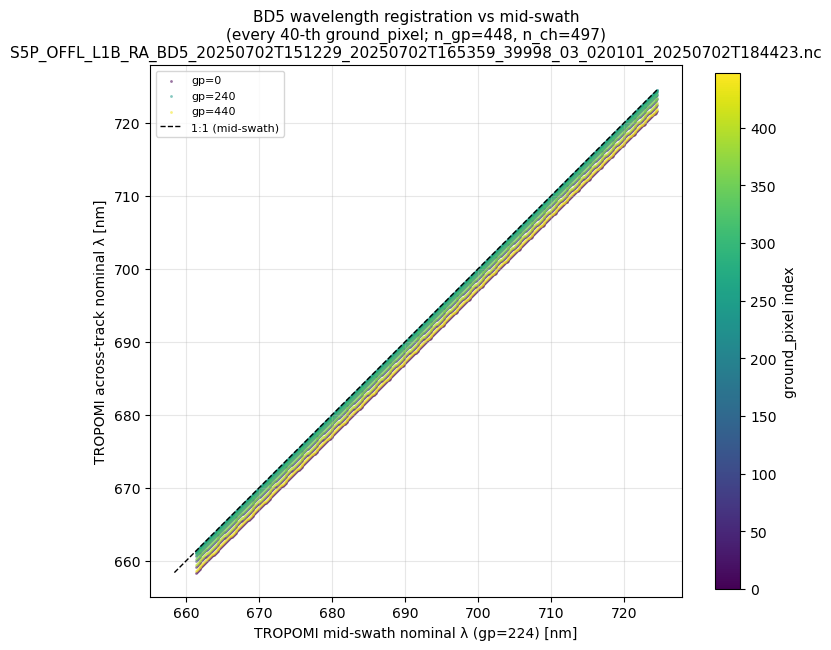

In [17]:
# TROPOMI nominal band + OCI red band wavelengths
# Requires tropo_path / pace_paths from the match-up plot cell (or pixel_matches).

_trop = Path(tropo_path) if "tropo_path" in dir() else Path(pixel_matches["tropomi_path"])
_pace = (
    Path(pace_paths[0]) if "pace_paths" in dir() and len(pace_paths)
    else Path(pixel_matches["pace_paths"][0])
)

with nc.Dataset(_trop) as ds:
    wl_t = np.asarray(
        ds["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]["nominal_wavelength"][0, :, :],
        dtype=float,
    )  # (ground_pixel, spectral_channel)

with nc.Dataset(_pace) as ds:
    wl_o = np.asarray(ds["sensor_band_parameters"]["red_wavelength"][:], dtype=float)

# TROPOMI: summarize across-track (wavelengths vary by ground_pixel)
gp_mid = wl_t.shape[0] // 2
wl_t_mid = wl_t[gp_mid]
wl_t_edge0 = wl_t[0]
wl_t_edge1 = wl_t[-1]

print("=== TROPOMI BD5 nominal_wavelength ===")
print(f"  file: {_trop.name}")
print(f"  shape (ground_pixel, spectral_channel): {wl_t.shape}")
print(
    f"  mid-swath gp={gp_mid}: "
    f"n={np.isfinite(wl_t_mid).sum()}  "
    f"λ={np.nanmin(wl_t_mid):.3f}–{np.nanmax(wl_t_mid):.3f} nm  "
    f"Δλ_med={np.nanmedian(np.diff(wl_t_mid)):.4f} nm"
)
print(
    f"  edge gp=0:   λ={np.nanmin(wl_t_edge0):.3f}–{np.nanmax(wl_t_edge0):.3f} nm"
)
print(
    f"  edge gp=-1:  λ={np.nanmin(wl_t_edge1):.3f}–{np.nanmax(wl_t_edge1):.3f} nm"
)
print(f"  mid-swath first 8 λ: {np.round(wl_t_mid[:8], 3)}")
print(f"  mid-swath last  8 λ: {np.round(wl_t_mid[-8:], 3)}")

print("\n=== OCI red_wavelength ===")
print(f"  file: {_pace.name}")
print(f"  shape: {wl_o.shape}  n={wl_o.size}")
print(
    f"  λ={wl_o[0]:.3f}–{wl_o[-1]:.3f} nm  "
    f"Δλ_med={np.median(np.diff(wl_o)):.4f} nm"
)
print(f"  first 8 λ: {np.round(wl_o[:8], 3)}")
print(f"  last  8 λ: {np.round(wl_o[-8:], 3)}")


# ── scatter: x = mid-swath λ, y = each across-track detector λ (same channel) ──
# One series per ground_pixel: y = nominal_wavelength[gp, :], x = mid-swath
GP_STRIDE = 40  # plot every N-th across-track pixel (set 1 for all)

n_gp, n_ch = wl_t.shape
gp_ids = np.arange(0, n_gp, GP_STRIDE)
# exclude mid itself from "each" or include — include all sampled gps

fig, ax = plt.subplots(figsize=(7.5, 7))
cmap = plt.cm.viridis
norm = plt.Normalize(0, n_gp - 1)
x_mid = wl_t_mid  # (n_ch,)

for gp in gp_ids:
    y = wl_t[gp]
    m = np.isfinite(x_mid) & np.isfinite(y)
    ax.scatter(
        x_mid[m], y[m],
        s=4, c=[cmap(norm(gp))], alpha=0.55, linewidths=0,
        label=f"gp={gp}" if gp in (gp_ids[0], gp_ids[len(gp_ids)//2], gp_ids[-1]) else None,
    )

# 1:1 reference
lim0 = float(np.nanmin(wl_t))
lim1 = float(np.nanmax(wl_t))
ax.plot([lim0, lim1], [lim0, lim1], "k--", lw=1.0, label="1:1 (mid-swath)")

ax.set_xlabel(f"TROPOMI mid-swath nominal λ (gp={gp_mid}) [nm]")
ax.set_ylabel("TROPOMI across-track nominal λ [nm]")
ax.set_title(
    f"BD5 wavelength registration vs mid-swath\n"
    f"(every {GP_STRIDE}-th ground_pixel; n_gp={n_gp}, n_ch={n_ch})\n{_trop.name}",
    fontsize=11,
)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.3)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, shrink=0.8, label="ground_pixel index")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()


> Note that this is an insignificant spectral shift of nominal bands for cross-track sensors

In [18]:
# RSR kernels: TROPOMI BD5 spectra → OCI red bands (per cross-track ground_pixel)
# Follows global_svd_fit_pipeline / Instrument.jl:
#   interpolate PACE RSR onto sensor λ grid, row-normalize → K @ spectrum
# File layout: RSR(bands, wavelength); we use RSR[ib, :] on `wavelength`.

from scipy.interpolate import interp1d

PACE_RSR_PATH = Path("/home/zhe2/data/MyProjects/PACE_redSIF_PACE/PACE_OCI/PACE_OCI_RSRs.nc")
# OCI bands to keep (nm); clip to TROPOMI BD5 coverage (+ margin)
OCI_BAND_MIN, OCI_BAND_MAX = 660.0, 720.0
CLIP_NEGATIVE = True

_trop = Path(tropo_path) if "tropo_path" in dir() else Path(pixel_matches["tropomi_path"])

# ── load PACE RSR (same variables as build_kernel_from_rsr_nc) ─────────────────
with nc.Dataset(PACE_RSR_PATH) as ds:
    rsr_wavlen = np.asarray(ds["wavelength"][:], dtype=float)       # (n_wl_rsr,)
    rsr_bands_all = np.asarray(ds["bands"][:], dtype=float)         # (n_band_all,)
    # NetCDF: RSR(bands, wavelength); Instrument.jl expects column-per-band on wvlen
    rsr_all = np.asarray(ds["RSR"][:, :], dtype=float)              # (n_band_all, n_wl_rsr)

print(f"Loaded PACE RSR: {PACE_RSR_PATH}")
print(f"  wavelength: {rsr_wavlen[0]:.2f}–{rsr_wavlen[-1]:.2f} nm  n={rsr_wavlen.size}")
print(f"  bands:      {rsr_bands_all[0]:.2f}–{rsr_bands_all[-1]:.2f} nm  n={rsr_bands_all.size}")
print(f"  RSR shape:  {rsr_all.shape}  (bands × wavelength)")

# ── load TROPOMI nominal λ per ground_pixel ───────────────────────────────────
with nc.Dataset(_trop) as ds:
    trop_wl = np.asarray(
        ds["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]["nominal_wavelength"][0, :, :],
        dtype=float,
    )  # (n_gp, n_ch)

n_gp, n_ch = trop_wl.shape
wl_t_lo = float(np.nanmin(trop_wl))
wl_t_hi = float(np.nanmax(trop_wl))

# select OCI bands in window ∩ TROPOMI coverage
band_ok = (
    (rsr_bands_all >= OCI_BAND_MIN)
    & (rsr_bands_all <= OCI_BAND_MAX)
    & (rsr_bands_all > wl_t_lo)
    & (rsr_bands_all < wl_t_hi)
)
ib = np.flatnonzero(band_ok)
oci_bands = rsr_bands_all[ib]
rsr_sel = rsr_all[ib, :]  # (n_oci, n_wl_rsr)
if CLIP_NEGATIVE:
    rsr_sel = np.maximum(rsr_sel, 0.0)

n_oci = oci_bands.size
print(
    f"OCI bands for kernels: n={n_oci}  "
    f"λ={oci_bands[0]:.2f}–{oci_bands[-1]:.2f} nm  "
    f"(TROPOMI coverage {wl_t_lo:.2f}–{wl_t_hi:.2f} nm)"
)

def build_kernel_for_wl_out(wl_out: np.ndarray, rsr_b: np.ndarray, wavlen: np.ndarray) -> np.ndarray:
    """Interpolate RSR onto wl_out and L1-normalize rows. Returns K (n_band, n_out)."""
    m_out = np.isfinite(wl_out)
    n_out = wl_out.size
    n_b = rsr_b.shape[0]
    K = np.zeros((n_b, n_out), dtype=np.float64)
    # RSR source knots must be finite / sorted
    m_src = np.isfinite(wavlen) & np.all(np.isfinite(rsr_b), axis=0)
    x = wavlen[m_src]
    for i in range(n_b):
        y = rsr_b[i, m_src]
        if CLIP_NEGATIVE:
            y = np.maximum(y, 0.0)
        f = interp1d(x, y, kind="linear", bounds_error=False, fill_value=0.0)
        row = np.zeros(n_out, dtype=np.float64)
        row[m_out] = f(wl_out[m_out])
        row = np.maximum(row, 0.0)
        s = row.sum()
        if s > 0:
            row /= s
        K[i] = row
    return K

# ── kernels for every cross-track ground_pixel ────────────────────────────────
# trop_oci_K[gp] @ trop_spectrum[gp]  →  OCI-band radiances
trop_oci_K = np.zeros((n_gp, n_oci, n_ch), dtype=np.float64)
for gp in range(n_gp):
    trop_oci_K[gp] = build_kernel_for_wl_out(trop_wl[gp], rsr_sel, rsr_wavlen)

# sanity: row sums ≈ 1 where spectrum covers the band
row_sums = trop_oci_K.sum(axis=2)
print(
    f"Built trop_oci_K shape={trop_oci_K.shape}  "
    f"(n_gp, n_oci_bands, n_trop_channels)"
)
print(
    f"  row-sum: min={row_sums.min():.4f}  max={row_sums.max():.4f}  "
    f"mean={row_sums.mean():.4f}"
)

# weighted center vs nominal band (mid-swath kernel)
gp_mid = n_gp // 2
K_mid = trop_oci_K[gp_mid]
centers = np.nansum(K_mid * trop_wl[gp_mid][None, :], axis=1)
print(
    f"  mid-swath center−band: mean={np.nanmean(centers - oci_bands):+.4f} nm  "
    f"|max|={np.nanmax(np.abs(centers - oci_bands)):.4f} nm"
)

rsr_bundle = {
    "path": str(PACE_RSR_PATH),
    "tropomi_path": str(_trop),
    "rsr_wavlen": rsr_wavlen,
    "rsr_bands_all": rsr_bands_all,
    "rsr_sel": rsr_sel,          # native RSR on rsr_wavlen for selected OCI bands
    "oci_bands": oci_bands,
    "trop_wl": trop_wl,          # (n_gp, n_ch)
    "K": trop_oci_K,             # (n_gp, n_oci, n_ch)
    "gp_mid": gp_mid,
    "band_min": OCI_BAND_MIN,
    "band_max": OCI_BAND_MAX,
}
print("Stored rsr_bundle keys:", list(rsr_bundle.keys()))


Loaded PACE RSR: /home/zhe2/data/MyProjects/PACE_redSIF_PACE/PACE_OCI/PACE_OCI_RSRs.nc
  wavelength: 306.00–2398.50 nm  n=20926
  bands:      314.55–2258.43 nm  n=286
  RSR shape:  (286, 20926)  (bands × wavelength)
OCI bands for kernels: n=46  λ=660.83–719.30 nm  (TROPOMI coverage 658.39–724.51 nm)


/tmp/ipykernel_909099/1521851554.py:28: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(_trop) as ds:


Built trop_oci_K shape=(448, 46, 497)  (n_gp, n_oci_bands, n_trop_channels)
  row-sum: min=1.0000  max=1.0000  mean=1.0000
  mid-swath center−band: mean=+0.0787 nm  |max|=1.7787 nm
Stored rsr_bundle keys: ['path', 'tropomi_path', 'rsr_wavlen', 'rsr_bands_all', 'rsr_sel', 'oci_bands', 'trop_wl', 'K', 'gp_mid', 'band_min', 'band_max']


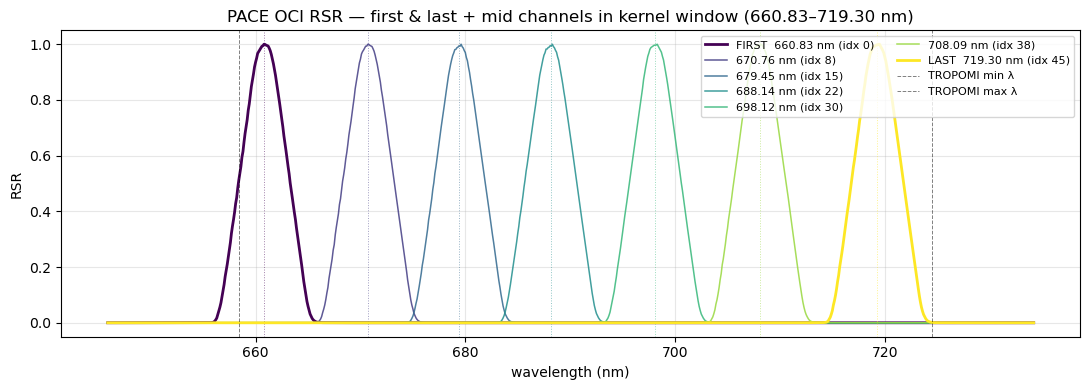

Plotted 7 RSRs; first=660.8350 nm (idx 0), last=719.2950 nm (idx 45)


In [19]:
# Plot OCI RSR: overlay several channels (incl. first & last) on one axes

if "rsr_bundle" not in globals():
    raise RuntimeError("Run the RSR kernel cell first.")

oci_bands = rsr_bundle["oci_bands"]
rsr_wavlen = rsr_bundle["rsr_wavlen"]
rsr_sel = rsr_bundle["rsr_sel"]

n_b = len(oci_bands)
# first, last, and a few evenly spaced interior channels
band_pick = np.unique(
    np.concatenate([
        [0, n_b - 1],
        np.round(np.linspace(0, n_b - 1, 7)).astype(int),
    ])
)

wl_lo = float(oci_bands[0]) - 15
wl_hi = float(oci_bands[-1]) + 15
m = (rsr_wavlen >= wl_lo) & (rsr_wavlen <= wl_hi)

fig, ax = plt.subplots(figsize=(11, 4))
cmap = plt.cm.viridis
norm = plt.Normalize(0, n_b - 1)

for ib in band_pick:
    y = rsr_sel[ib]
    is_edge = ib in (0, n_b - 1)
    ax.plot(
        rsr_wavlen[m], y[m],
        color=cmap(norm(ib)),
        lw=2.0 if is_edge else 1.1,
        alpha=1.0 if is_edge else 0.85,
        label=(
            f"{'FIRST' if ib == 0 else 'LAST'}  "
            f"{oci_bands[ib]:.2f} nm (idx {ib})"
            if is_edge
            else f"{oci_bands[ib]:.2f} nm (idx {ib})"
        ),
    )
    ax.axvline(oci_bands[ib], color=cmap(norm(ib)), ls=":", lw=0.7, alpha=0.5)

# avline for tropomi min and max wavelength
ax.axvline(wl_t_lo, color="k", ls="--", lw=0.7, alpha=0.5, label="TROPOMI min λ")
ax.axvline(wl_t_hi, color="k", ls="--", lw=0.7, alpha=0.5, label="TROPOMI max λ")

ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("RSR")
ax.set_title(
    f"PACE OCI RSR — first & last + mid channels in kernel window "
    f"({oci_bands[0]:.2f}–{oci_bands[-1]:.2f} nm)",
    fontsize=12,
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

print(
    f"Plotted {len(band_pick)} RSRs; "
    f"first={oci_bands[0]:.4f} nm (idx 0), "
    f"last={oci_bands[-1]:.4f} nm (idx {n_b - 1})"
)


In [20]:
# Read PACE OCI baseline SNR LUT (same file / logic as global_svd_fit_pipeline)
# File: PACE_OCI_L1BLUT_baseline_SNR_1.1.txt
# SNR(L) = L / sqrt(c1 + c2*L)  with L in W m^-2 sr^-1 µm^-1
# Pipeline ref: load_pace_band_snr_coeffs in svd_retrieval/svd_helpers.jl

PACE_OCI_DIR = Path("/home/zhe2/data/MyProjects/PACE_redSIF_PACE/PACE_OCI")
PACE_SNR_PATH = PACE_OCI_DIR / "PACE_OCI_L1BLUT_baseline_SNR_1.1.txt"
SNR_FPA = "Red"
SNR_WL_MIN, SNR_WL_MAX = 600.0, 900.0  # Red band window in LUT

def load_pace_band_snr_table(
    path: Path,
    fpa: str = "Red",
    λ_min: float = 600.0,
    λ_max: float = 900.0,
):
    """Parse baseline SNR txt → sorted Red-band λ, c1, c2 (pipeline skip-/end_header)."""
    lines = path.read_text().splitlines()
    header_end = next(i for i, ln in enumerate(lines) if "/end_header" in ln)
    # data rows after header (tab-delimited: FPA, center_wl, band_index, c1, c2)
    rows = []
    for ln in lines[header_end + 1 :]:
        ln = ln.strip()
        if not ln or ln.startswith("!"):
            continue
        parts = ln.split()
        if len(parts) < 5 or parts[0] != fpa:
            continue
        wl = float(parts[1])
        if not (λ_min <= wl <= λ_max):
            continue
        rows.append((wl, int(float(parts[2])), float(parts[3]), float(parts[4])))
    if not rows:
        raise RuntimeError(f"No {fpa} SNR rows in ({λ_min}, {λ_max}) nm in {path}")
    rows.sort(key=lambda r: r[0])
    wl = np.array([r[0] for r in rows], dtype=float)
    band_index = np.array([r[1] for r in rows], dtype=int)
    c1 = np.array([r[2] for r in rows], dtype=float)
    c2 = np.array([r[3] for r in rows], dtype=float)
    return {"wavelength": wl, "band_index": band_index, "c1": c1, "c2": c2, "fpa": fpa}

def interp_snr_coeffs(snr_tab: dict, λ_target: np.ndarray):
    """Interpolate c1,c2 onto λ_target (Flat extrapolation), as in load_pace_band_snr_coeffs."""
    wl = snr_tab["wavelength"]
    c1_t = np.interp(λ_target, wl, snr_tab["c1"], left=snr_tab["c1"][0], right=snr_tab["c1"][-1])
    c2_t = np.interp(λ_target, wl, snr_tab["c2"], left=snr_tab["c2"][0], right=snr_tab["c2"][-1])
    return {"c1": c1_t, "c2": c2_t, "wavelength": np.asarray(λ_target, dtype=float)}

def snr_from_L(L, c1, c2):
    """SNR = L / sqrt(c1 + c2*L)."""
    return L / np.sqrt(c1 + c2 * L)

pace_snr_table = load_pace_band_snr_table(
    PACE_SNR_PATH, fpa=SNR_FPA, λ_min=SNR_WL_MIN, λ_max=SNR_WL_MAX
)
print(f"Loaded SNR LUT: {PACE_SNR_PATH.name}")
print(
    f"  FPA={pace_snr_table['fpa']}  n={pace_snr_table['wavelength'].size}  "
    f"λ={pace_snr_table['wavelength'][0]:.3f}–{pace_snr_table['wavelength'][-1]:.3f} nm"
)
print(
    f"  c1 range [{pace_snr_table['c1'].min():.4g}, {pace_snr_table['c1'].max():.4g}]  "
    f"c2 range [{pace_snr_table['c2'].min():.4g}, {pace_snr_table['c2'].max():.4g}]"
)

# If OCI band centers from RSR kernels exist, interpolate coeffs onto them
pace_snr_coeffs = None
if "rsr_bundle" in globals() and "oci_bands" in rsr_bundle:
    λ_tgt = np.asarray(rsr_bundle["oci_bands"], dtype=float)
    pace_snr_coeffs = interp_snr_coeffs(pace_snr_table, λ_tgt)
    print(
        f"Interpolated c1,c2 onto rsr_bundle oci_bands "
        f"(n={λ_tgt.size}, {λ_tgt[0]:.2f}–{λ_tgt[-1]:.2f} nm)"
    )
else:
    print("rsr_bundle.oci_bands not available — stored table only (interpolate later).")

pace_snr = {
    "path": str(PACE_SNR_PATH),
    "table": pace_snr_table,       # native Red LUT rows
    "coeffs": pace_snr_coeffs,     # c1,c2 on oci_bands if available
}
print("Stored pace_snr keys:", list(pace_snr.keys()))


Loaded SNR LUT: PACE_OCI_L1BLUT_baseline_SNR_1.1.txt
  FPA=Red  n=163  λ=600.545–894.602 nm
  c1 range [1.949e-05, 0.0008163]  c2 range [1.197e-05, 3.7e-05]
Interpolated c1,c2 onto rsr_bundle oci_bands (n=46, 660.83–719.30 nm)
Stored pace_snr keys: ['path', 'table', 'coeffs']


> Adding white noise: spectrally uncorrelated

Spectrum SVD row=1000  flat=125855 → gp=382  (mid=224)
Current recon N_PC=10; compare N_PC=5
OCI bands n=46  (660.83–719.30 nm)
SNR white noise on conv_gp: σ median=0.01229  SNR median=825.8


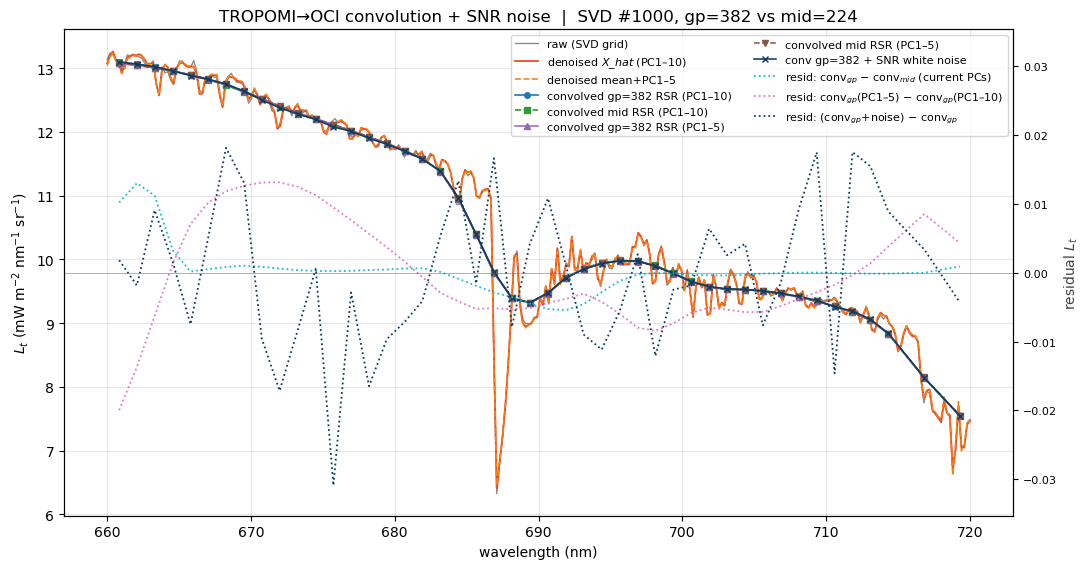

In [21]:
# Convolve denoised TROPOMI spectrum to OCI bands
# (1) pixel gp RSR  (2) mid-swath RSR
# Also: reconstruct with mean+5 PCs; add SNR white noise on conv_gp; twinx residuals.
# Requires: trop_svd, rsr_bundle, pace_snr (SNR cell), match-cell strides/shape.

SPEC_IDX = 1000
N_PC_CMP = 5  # low-rank compare (mean + first N_PC_CMP)
NOISE_SEED = 0

if "trop_svd" not in globals() or "X_hat" not in trop_svd:
    raise RuntimeError("Run SVD + resynthesize cells first (needs trop_svd['X_hat']).")
if "rsr_bundle" not in globals():
    raise RuntimeError("Run the RSR kernel cell first (needs rsr_bundle).")
if "pace_snr" not in globals() or pace_snr.get("coeffs") is None:
    raise RuntimeError("Run the SNR cell first (needs pace_snr['coeffs'] on oci_bands).")

wl = trop_svd["wl"]
U = trop_svd["U"]
s = trop_svd["s"]
Vt = trop_svd["Vt"]
mean_spec = trop_svd["mean"]
N_PC_CUR = int(trop_svd.get("N_PC_recon", s.size))
N_PC_CMP = min(N_PC_CMP, s.size, N_PC_CUR)

X_raw = trop_svd["X"][SPEC_IDX]
X_den = trop_svd["X_hat"][SPEC_IDX]  # mean + current N_PC
X_den_5 = mean_spec + (U[SPEC_IDX, :N_PC_CMP] * s[:N_PC_CMP]) @ Vt[:N_PC_CMP, :]

flat_i = int(trop_svd["idx"][SPEC_IDX])
scan_sub, pix_sub = np.unravel_index(flat_i, trop_shape)
gp = int(np.clip(pix_sub * TROPO_PIX_STRIDE, 0, rsr_bundle["K"].shape[0] - 1))
gp_mid = int(rsr_bundle["gp_mid"])

oci_bands = rsr_bundle["oci_bands"]
trop_wl_gp = rsr_bundle["trop_wl"][gp]
trop_wl_mid = rsr_bundle["trop_wl"][gp_mid]
K_gp = rsr_bundle["K"][gp]
K_mid = rsr_bundle["K"][gp_mid]

def _fill_nan(y):
    y = np.asarray(y, dtype=float).copy()
    ok = np.isfinite(y)
    if not ok.any():
        return y
    idx = np.where(ok, np.arange(y.size), 0)
    np.maximum.accumulate(idx, out=idx)
    y[~ok] = y[idx[~ok]]
    first = int(np.argmax(ok))
    y[:first] = y[first]
    return y

def _to_native_and_convolve(spec_svd, wl_native, K):
    spec_n = _fill_nan(np.interp(wl_native, wl, spec_svd, left=np.nan, right=np.nan))
    return K @ spec_n

# current N_PC convolutions
oci_gp = _to_native_and_convolve(X_den, trop_wl_gp, K_gp)
oci_mid = _to_native_and_convolve(X_den, trop_wl_mid, K_mid)
# N_PC_CMP convolutions (same kernels)
oci_gp_5 = _to_native_and_convolve(X_den_5, trop_wl_gp, K_gp)
oci_mid_5 = _to_native_and_convolve(X_den_5, trop_wl_mid, K_mid)

# ── SNR white noise on conv_gp (current PCs) ──────────────────────────────────
# LUT: SNR = L / sqrt(c1 + c2*L)  →  σ = sqrt(c1 + c2*L) = L/SNR
# L must be in W m^-2 sr^-1 µm^-1 ≡ mW m^-2 nm^-1 sr^-1 (same number as our Lt)
c1 = np.asarray(pace_snr["coeffs"]["c1"], dtype=float)
c2 = np.asarray(pace_snr["coeffs"]["c2"], dtype=float)
if c1.shape != oci_gp.shape:
    # re-interp onto current oci_bands if needed
    tab = pace_snr["table"]
    c1 = np.interp(oci_bands, tab["wavelength"], tab["c1"], left=tab["c1"][0], right=tab["c1"][-1])
    c2 = np.interp(oci_bands, tab["wavelength"], tab["c2"], left=tab["c2"][0], right=tab["c2"][-1])

L = np.maximum(oci_gp, 0.0)
sigma = np.sqrt(np.maximum(c1 + c2 * L, 0.0))
snr = np.divide(L, sigma, out=np.full_like(L, np.nan), where=sigma > 0)

rng = np.random.default_rng(NOISE_SEED)
noise = rng.normal(loc=0.0, scale=sigma)
oci_gp_noisy = oci_gp + noise

print(
    f"Spectrum SVD row={SPEC_IDX}  flat={flat_i} → gp={gp}  (mid={gp_mid})\n"
    f"Current recon N_PC={N_PC_CUR}; compare N_PC={N_PC_CMP}\n"
    f"OCI bands n={oci_bands.size}  ({oci_bands[0]:.2f}–{oci_bands[-1]:.2f} nm)\n"
    f"SNR white noise on conv_gp: σ median={np.nanmedian(sigma):.4g}  "
    f"SNR median={np.nanmedian(snr):.1f}"
)

# residuals for twinx
d_gp_minus_mid = oci_gp - oci_mid
d_5pc_minus_cur = oci_gp_5 - oci_gp
d_noisy_minus_gp = oci_gp_noisy - oci_gp  # = noise draw

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.plot(wl, X_raw, color="0.55", lw=1.0, label="raw (SVD grid)")
ax.plot(wl, X_den, color="#EC4B26", lw=1.3, label=fr"denoised $X\_hat$ (PC1–{N_PC_CUR})")
ax.plot(
    wl, X_den_5, color="#ff7f0e", lw=1.15, ls="--",
    label=fr"denoised mean+PC1–{N_PC_CMP}",
)
ax.plot(
    oci_bands, oci_gp, "o-", color="#1f77b4", ms=4, lw=1.2,
    label=f"convolved gp={gp} RSR (PC1–{N_PC_CUR})",
)
ax.plot(
    oci_bands, oci_mid, "s--", color="#2ca02c", ms=4, lw=1.2,
    label=f"convolved mid RSR (PC1–{N_PC_CUR})",
)
ax.plot(
    oci_bands, oci_gp_5, "^-", color="#9467bd", ms=4, lw=1.1,
    label=f"convolved gp={gp} RSR (PC1–{N_PC_CMP})",
)
ax.plot(
    oci_bands, oci_mid_5, "v--", color="#8c564b", ms=4, lw=1.1,
    label=f"convolved mid RSR (PC1–{N_PC_CMP})",
)
ax.plot(
    oci_bands, oci_gp_noisy, "x-", color="#0d3b66", ms=5, lw=1.15,
    label=f"conv gp={gp} + SNR white noise",
)
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel(r"$L_t$ (mW m$^{-2}$ nm$^{-1}$ sr$^{-1}$)")
ax.set_title(
    f"TROPOMI→OCI convolution + SNR noise  |  SVD #{SPEC_IDX}, gp={gp} vs mid={gp_mid}",
    fontsize=12,
)
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
ax2.plot(
    oci_bands, d_gp_minus_mid, ":", color="#17becf", lw=1.3,
    label=r"resid: conv$_{gp}$ − conv$_{mid}$ (current PCs)",
)
ax2.plot(
    oci_bands, d_5pc_minus_cur, ":", color="#e377c2", lw=1.3,
    label=fr"resid: conv$_{{gp}}$(PC1–{N_PC_CMP}) − conv$_{{gp}}$(PC1–{N_PC_CUR})",
)
ax2.plot(
    oci_bands, d_noisy_minus_gp, ":", color="#0d3b66", lw=1.3,
    label=r"resid: (conv$_{gp}$+noise) − conv$_{gp}$",
)
ax2.axhline(0.0, color="0.4", lw=0.6, alpha=0.6)
rmax = float(
    np.nanpercentile(
        np.abs(np.concatenate([d_gp_minus_mid, d_5pc_minus_cur, d_noisy_minus_gp])),
        98,
    )
) * 2 or 1.0
ax2.set_ylim(-rmax, rmax)
ax2.set_ylabel("residual $L_t$", color="0.25")
ax2.tick_params(axis="y", labelsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="best", ncol=2)
plt.tight_layout()
plt.show()


## From sample to a wrap-up function

In [22]:
# Function: denoise (N_PC) → convolve (per ground_pixel RSR) → optional SNR white noise
# Depends on trop_svd, rsr_bundle, pace_snr from earlier cells.

Na = 6.022e23
h = 6.626e-34
c_light = 2.998e8

def tropomi_mol_to_mW(radiance_mol, wavelength_nm):
    """mol s-1 m-2 nm-1 sr-1 → mW m-2 nm-1 sr-1."""
    return radiance_mol * (h * c_light * Na / wavelength_nm) * 1e9 * 1e3

def _fill_nan_1d(y: np.ndarray) -> np.ndarray:
    y = np.asarray(y, dtype=float).copy()
    ok = np.isfinite(y)
    if not ok.any():
        return y
    idx = np.where(ok, np.arange(y.size), 0)
    np.maximum.accumulate(idx, out=idx)
    y[~ok] = y[idx[~ok]]
    first = int(np.argmax(ok))
    y[:first] = y[first]
    return y

def denoise_with_svd(
    spec_on_svd_wl: np.ndarray,
    trop_svd: dict,
    n_pc: int,
) -> np.ndarray:
    """Project onto first n_pc right singular vectors: mean + ((y-mean) V_k^T) V_k."""
    mean = trop_svd["mean"]
    Vt = trop_svd["Vt"]
    k = min(int(n_pc), Vt.shape[0])
    y = np.asarray(spec_on_svd_wl, dtype=float)
    xc = y - mean
    coeffs = xc @ Vt[:k].T
    return mean + coeffs @ Vt[:k]

def snr_sigma_from_L(L: np.ndarray, c1: np.ndarray, c2: np.ndarray) -> np.ndarray:
    """σ = sqrt(c1 + c2*L); L in W m^-2 sr^-1 µm^-1 ≡ mW m^-2 nm^-1 sr^-1."""
    L = np.maximum(np.asarray(L, dtype=float), 0.0)
    return np.sqrt(np.maximum(c1 + c2 * L, 0.0))

def tropomi_to_oci(
    lt_native: np.ndarray,
    gp: int,
    n_pc: int,
    *,
    trop_svd: dict,
    rsr_bundle: dict,
    pace_snr: dict,
    add_noise: bool = True,
    rng: np.random.Generator | None = None,
) -> dict:
    """
    Convert one TROPOMI BD5 radiance spectrum to simulated OCI-band radiances.

    Steps
    -----
    1. Interpolate native TROPOMI Lt onto SVD wavelength grid
    2. Denoise with mean + first ``n_pc`` PCs from ``trop_svd``
    3. Convolve with cross-track RSR kernel ``rsr_bundle['K'][gp]``
    4. Optionally add Gaussian white noise with σ from PACE SNR LUT

    Parameters
    ----------
    lt_native : (n_ch,) TROPOMI radiance on that ground_pixel's nominal λ
    gp : TROPOMI ground_pixel index (native, for RSR smile)
    n_pc : number of SVD PCs for denoise

    Returns
    -------
    dict with oci_bands, lt_den_svd, lt_oci, lt_oci_noisy, sigma, snr, gp, n_pc
    """
    wl_svd = trop_svd["wl"]
    trop_wl_gp = rsr_bundle["trop_wl"][gp]
    K = rsr_bundle["K"][gp]
    oci_bands = rsr_bundle["oci_bands"]

    lt_native = _fill_nan_1d(lt_native)
    # onto SVD grid
    m = np.isfinite(trop_wl_gp)
    order = np.argsort(trop_wl_gp[m])
    spec_svd = np.interp(
        wl_svd, trop_wl_gp[m][order], lt_native[m][order], left=np.nan, right=np.nan
    )
    spec_svd = _fill_nan_1d(spec_svd)

    lt_den = denoise_with_svd(spec_svd, trop_svd, n_pc)

    # denoise back onto native λ for this gp's kernel
    spec_native_den = _fill_nan_1d(
        np.interp(trop_wl_gp, wl_svd, lt_den, left=np.nan, right=np.nan)
    )
    lt_oci = K @ spec_native_den

    # SNR coeffs on oci_bands
    if pace_snr.get("coeffs") is not None and np.array_equal(
        np.asarray(pace_snr["coeffs"]["wavelength"]), oci_bands
    ):
        c1 = np.asarray(pace_snr["coeffs"]["c1"], dtype=float)
        c2 = np.asarray(pace_snr["coeffs"]["c2"], dtype=float)
    else:
        tab = pace_snr["table"]
        c1 = np.interp(oci_bands, tab["wavelength"], tab["c1"], left=tab["c1"][0], right=tab["c1"][-1])
        c2 = np.interp(oci_bands, tab["wavelength"], tab["c2"], left=tab["c2"][0], right=tab["c2"][-1])

    sigma = snr_sigma_from_L(lt_oci, c1, c2)
    snr = np.divide(np.maximum(lt_oci, 0.0), sigma, out=np.full_like(lt_oci, np.nan), where=sigma > 0)

    if add_noise:
        if rng is None:
            rng = np.random.default_rng()
        noise = rng.normal(0.0, sigma)
        lt_oci_noisy = lt_oci + noise
    else:
        noise = np.zeros_like(lt_oci)
        lt_oci_noisy = lt_oci.copy()

    return {
        "oci_bands": oci_bands,
        "lt_svd_grid": spec_svd,
        "lt_den_svd": lt_den,
        "lt_oci": lt_oci,
        "lt_oci_noisy": lt_oci_noisy,
        "sigma": sigma,
        "snr": snr,
        "noise": noise,
        "gp": int(gp),
        "n_pc": int(n_pc),
    }

print(
    "Defined tropomi_to_oci(lt_native, gp, n_pc, *, trop_svd, rsr_bundle, pace_snr, "
    "add_noise=True, rng=None)"
)


Defined tropomi_to_oci(lt_native, gp, n_pc, *, trop_svd, rsr_bundle, pace_snr, add_noise=True, rng=None)


Match-ups: 47  unique TROPOMI pixels: 47  N_PC=10  noise=True


/tmp/ipykernel_909099/287389713.py:37: UserWarning: WARNING: unsupported Compound type, skipping...
  with nc.Dataset(trop_path) as ds:


Stored match_oci: lt_oci / lt_oci_noisy shape=(47, 46)  (n_match × n_oci=46)
  finite clean=47 / 47  median σ=0.01591
Matched OCI Lt loaded: finite=47 / 47  µ_t/µ_o median=0.970


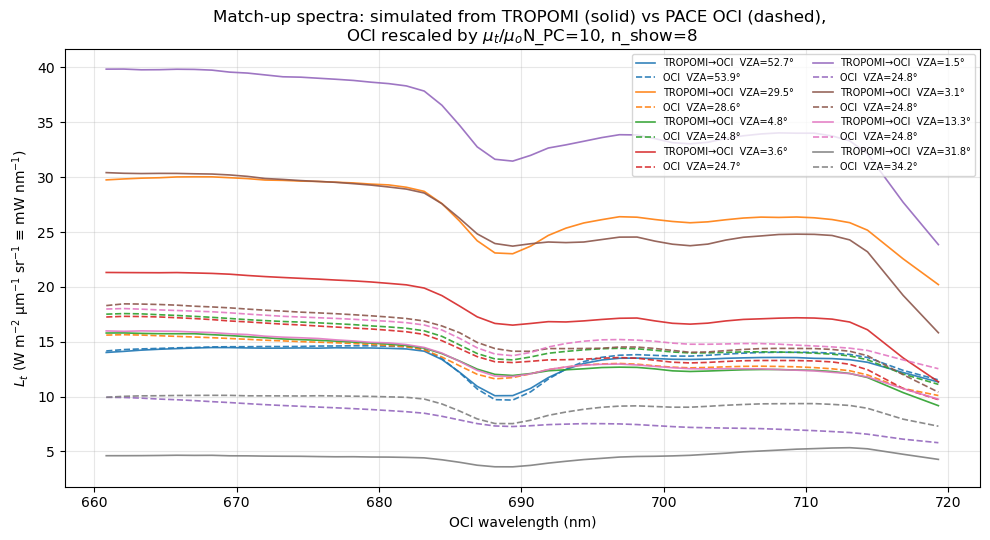

In [31]:
# Apply tropomi_to_oci to all match-up TROPOMI spectra in pixel_matches
# denoise → gp RSR convolve → SNR white noise

N_PC = 10
NOISE_SEED = 0
ADD_NOISE = True

if "pixel_matches" not in globals() or pixel_matches is None:
    raise RuntimeError("Run the pixel match-up cell first.")
if "trop_svd" not in globals() or "rsr_bundle" not in globals() or "pace_snr" not in globals():
    raise RuntimeError("Need trop_svd, rsr_bundle, and pace_snr.")
if "tropomi_to_oci" not in globals():
    raise RuntimeError("Run the tropomi_to_oci function cell first.")

trop_path = Path(pixel_matches["tropomi_path"])
n_match = len(pixel_matches["dist_km"])
trop_scan = np.asarray(pixel_matches["trop_scan"], dtype=np.int64)
trop_pix = np.asarray(pixel_matches["trop_pix"], dtype=np.int64)

# unique TROPOMI footprints to avoid repeat I/O / conversion
pairs = np.stack([trop_scan, trop_pix], axis=1)
uniq, inv = np.unique(pairs, axis=0, return_inverse=True)
print(
    f"Match-ups: {n_match:,}  unique TROPOMI pixels: {uniq.shape[0]:,}  "
    f"N_PC={N_PC}  noise={ADD_NOISE}"
)

n_oci = rsr_bundle["oci_bands"].size
oci_clean_u = np.full((uniq.shape[0], n_oci), np.nan, dtype=np.float32)
oci_noisy_u = np.full((uniq.shape[0], n_oci), np.nan, dtype=np.float32)
sigma_u = np.full((uniq.shape[0], n_oci), np.nan, dtype=np.float32)
gp_u = np.zeros(uniq.shape[0], dtype=np.int32)

rng = np.random.default_rng(NOISE_SEED)
scans_needed = np.unique(uniq[:, 0])

with nc.Dataset(trop_path) as ds:
    inst = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["INSTRUMENT"]
    trop_wl_all = np.asarray(inst["nominal_wavelength"][0, :, :], dtype=float)
    rad = ds["BAND5_RADIANCE"]["STANDARD_MODE"]["OBSERVATIONS"]["radiance"]

    # index map (scan, pix) → row in uniq
    key_to_u = {(int(s), int(p)): i for i, (s, p) in enumerate(uniq)}

    for iscan in scans_needed:
        mol_scan = np.asarray(rad[0, int(iscan), :, :], dtype=float)  # (gp, λ)
        mol_scan = np.where(np.isfinite(mol_scan) & (mol_scan < 1e30), mol_scan, np.nan)
        pix_this = uniq[uniq[:, 0] == iscan, 1]
        for ipix in pix_this:
            ipix = int(ipix)
            u = key_to_u[(int(iscan), ipix)]
            gp = int(np.clip(ipix, 0, rsr_bundle["K"].shape[0] - 1))
            wl_gp = trop_wl_all[gp]
            lt = tropomi_mol_to_mW(mol_scan[gp], wl_gp)
            out = tropomi_to_oci(
                lt, gp, N_PC,
                trop_svd=trop_svd,
                rsr_bundle=rsr_bundle,
                pace_snr=pace_snr,
                add_noise=ADD_NOISE,
                rng=rng,
            )
            oci_clean_u[u] = out["lt_oci"]
            oci_noisy_u[u] = out["lt_oci_noisy"]
            sigma_u[u] = out["sigma"]
            gp_u[u] = gp

# expand unique → per match-up row
match_oci = {
    "n_pc": N_PC,
    "add_noise": ADD_NOISE,
    "noise_seed": NOISE_SEED,
    "oci_bands": np.asarray(rsr_bundle["oci_bands"], dtype=np.float32),
    "lt_oci": oci_clean_u[inv],
    "lt_oci_noisy": oci_noisy_u[inv],
    "sigma": sigma_u[inv],
    "trop_gp": gp_u[inv],
    "unique_scan": uniq[:, 0],
    "unique_pix": uniq[:, 1],
    "inv_unique": inv,
}
print(
    f"Stored match_oci: lt_oci / lt_oci_noisy shape={match_oci['lt_oci'].shape}  "
    f"(n_match × n_oci={n_oci})"
)
print(
    f"  finite clean={np.isfinite(match_oci['lt_oci']).all(axis=1).sum():,} / {n_match:,}  "
    f"median σ={np.nanmedian(match_oci['sigma']):.4g}"
)

# ── load matched PACE OCI Lt and µ-rescale for plot / storage ─────────────────
# Lt_oci_meas = rhot * F0 * µ_oci / (π * esd)
# plot scale: Lt * (µ_trop / µ_oci)  so solar-cosine amplitude matches TROPOMI side
pace_path_by_name = {Path(p).name: Path(p) for p in pixel_matches["pace_paths"]}
oci_bands = match_oci["oci_bands"]
lt_oci_meas = np.full((n_match, n_oci), np.nan, dtype=np.float32)
mu_scale = np.full(n_match, np.nan, dtype=np.float32)  # µ_trop / µ_oci

pace_cache: dict[str, nc.Dataset] = {}
try:
    for j in range(n_match):
        pname = str(pixel_matches["pace_name"][j])
        pscan = int(pixel_matches["pace_scan"][j])
        ppix = int(pixel_matches["pace_pix"][j])
        sza_o = float(pixel_matches["pace_sza"][j])
        sza_t = float(pixel_matches["trop_sza"][j])
        mu_o = max(float(np.cos(np.deg2rad(sza_o))), 1e-6)
        mu_t = max(float(np.cos(np.deg2rad(sza_t))), 1e-6)
        mu_scale[j] = mu_t / mu_o

        if pname not in pace_cache:
            pace_cache[pname] = nc.Dataset(pace_path_by_name[pname])
        ds_p = pace_cache[pname]
        esd = float(getattr(ds_p, "earth_sun_distance_correction", 1.0))
        wl_oci = np.asarray(ds_p["sensor_band_parameters"]["red_wavelength"][:], dtype=float)
        f0 = np.asarray(ds_p["sensor_band_parameters"]["red_solar_irradiance"][:], dtype=float)
        rhot = np.asarray(ds_p["observation_data"]["rhot_red"][:, pscan, ppix], dtype=float)
        rhot = np.where(rhot > 0, rhot, np.nan)
        lt_full = rhot * f0 * mu_o / (np.pi * esd)  # W m^-2 sr^-1 µm^-1
        m = np.isfinite(wl_oci) & np.isfinite(lt_full)
        if m.sum() < 3:
            continue
        order = np.argsort(wl_oci[m])
        lt_oci_meas[j] = np.interp(
            oci_bands, wl_oci[m][order], lt_full[m][order], left=np.nan, right=np.nan
        )
finally:
    for ds_p in pace_cache.values():
        ds_p.close()

match_oci["lt_oci_meas"] = lt_oci_meas
match_oci["mu_trop_over_mu_oci"] = mu_scale
print(
    f"Matched OCI Lt loaded: finite={np.isfinite(lt_oci_meas).all(axis=1).sum():,} / {n_match:,}  "
    f"µ_t/µ_o median={np.nanmedian(mu_scale):.3f}"
)

# sanity plot: sim TROPOMI→OCI (solid) + matched OCI (dashed), µ-rescaled
n_show = min(8, n_match)
show_idx = np.linspace(0, n_match - 1, n_show, dtype=int)
fig, ax = plt.subplots(figsize=(10, 5.5))
cmap = plt.cm.tab10
for k, j in enumerate(show_idx):
    c = cmap(k % 10)
    scale = float(mu_scale[j])
    vza_t = float(pixel_matches["trop_vza"][j])
    vza_o = float(pixel_matches["pace_vza"][j])
    ax.plot(
        match_oci["oci_bands"], match_oci["lt_oci_noisy"][j],
        "-", color=c, lw=1.2, alpha=0.9,
        label=f"TROPOMI→OCI  VZA={vza_t:.1f}°",
    )
    ax.plot(
        match_oci["oci_bands"], lt_oci_meas[j] * scale,
        "--", color=c, lw=1.2, alpha=0.9,
        label=f"OCI  VZA={vza_o:.1f}°",
    )
ax.set_xlabel("OCI wavelength (nm)")
ax.set_ylabel(r"$L_t$ (W m$^{-2}$ µm$^{-1}$ sr$^{-1}$ ≡ mW nm$^{-1}$)")
ax.set_title(
    "Match-up spectra: simulated from TROPOMI (solid) vs PACE OCI (dashed), \n"
    r"OCI rescaled by $\mu_t/\mu_o$"
    f"N_PC={N_PC}, n_show={n_show}"
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc="best")
plt.tight_layout()
plt.show()


# Summary: co-location criteria & TROPOMI→OCI simulation

### Match-up criteria

**Granule pairing (TROPOMI BD5 L1B ↔ PACE OCI L1B)**
- Time windows from filenames, with a maximum mid-point / window separation of `DT_MAX_MIN` (default **30 min**).
- Geographic overlap via bounding boxes (with TROPOMI along-track chunking for antimeridian safety).
- Current exploration window: early July 2025 (`DAY_END`), subsampled PACE listing via `PACE_STRIDE`.

**Pixel pairing (within a chosen `MATCH_ID` swath)**
| Criterion | Default | Notes |
|-----------|---------|--------|
| Spatial distance | ≤ **2.5 km** | Great-circle nearest TROPOMI neighbor (KD-tree on subsampled grids) |
| Time difference \|Δt\| | ≤ **30 min** | Scan-line times (TROPOMI `time+δt`; OCI `scan_line_attributes/time`) |
| OCI dark-pixel prefilter | max \(L_t(\lambda\ge 600\,\mathrm{nm}) < **30**\) | \(L_t=\rho_t F_0\cos(\mathrm{SZA})/(\pi\,\mathrm{esd})\); applied *before* NN |
| Grid subsampling | PACE stride **150**; TROPOMI scan/pix stride **2** | Speed knob — not a science requirement |

Stored per-pair geometry includes lat/lon, SZA/VZA (both sensors), `dist_km`, `dt_min`.

---

### Method: simulating OCI spectra from TROPOMI

Pipeline implemented as `tropomi_to_oci(...)` and applied to all `pixel_matches`:

1. **Radiance units** — TROPOMI BD5 mol → mW m⁻² nm⁻¹ sr⁻¹ (same numerical scale as W m⁻² µm⁻¹).
2. **Denoise (SVD)** — Project onto a mean-centered BD5 basis trained on filtered TROPOMI pixels (`trop_ok`, SZA/VZA < 70°, \(L_t\) red < 30), common λ-grid ~660–720 nm. Retain the first **`N_PC`** components (parameter; e.g. 6–10).
3. **Spectral convolution** — PACE `PACE_OCI_RSRs.nc` RSRs interpolated onto each TROPOMI **ground_pixel** λ grid (accounts for spectral smile), row-normalized → \(L_\mathrm{OCI}=K_{\mathrm{gp}}\,L_\mathrm{TROPOMI}\). Bands kept in ~660–720 nm.
4. **Measurement noise** — Independent Gaussian draws per OCI band with  
   \(\sigma=\sqrt{c_1+c_2 L}=L/\mathrm{SNR}\) from `PACE_OCI_L1BLUT_baseline_SNR_1.1.txt` (Red FPA), following the SVD retrieval pipeline.
5. **Comparison plots** — Matched PACE OCI \(L_t\) overlaid after amplitude rescaling by \(\mu_t/\mu_o=\cos(\mathrm{SZA}_\mathrm{trop})/\cos(\mathrm{SZA}_\mathrm{oci})\).

Outputs live in `match_oci` (`lt_oci`, `lt_oci_noisy`, `sigma`, `lt_oci_meas`, `mu_trop_over_mu_oci`, …).

---

### Open problems / caveats

1. **VZA / BRDF / path mismatch** — \(\mu_0\) rescaling does **not** correct viewing-angle differences. Residual amplitude and absorption-band errors remain when \(|\Delta\mathrm{VZA}|\) (and RAA) is large; no BRDF or atmospheric path correction yet.
2. **Subsampling bias** — Coarse PACE/TROPOMI strides (and KD-tree on a thinned grid) can miss closer neighbors and undersample the swath; science runs need denser or full-resolution matching.
3. **OCI-only dark filter at match time** — Bright TROPOMI pixels are not rejected before pairing; only OCI \(L_t < 30\) is enforced in the match cell (TROPOMI dark cut is used for SVD training, not for every match-up).
4. **SVD domain transfer** — Denoising PCs are learned on dark, geometry-filtered TROPOMI spectra, then applied to match-ups that may have different radiance/geometry statistics; `N_PC` choice is heuristic (bias–variance / absorption retention).
5. **Interpolation stack** — Native TROPOMI λ → SVD grid → native λ → OCI bands introduces small spectral resampling errors; smile is handled via per-`gp` kernels but not keystone/ISRF detail.
6. **Noise model** — PACE prelaunch SNR LUT assumes OCI-like radiometry on the convolved spectrum; it does **not** propagate TROPOMI L1 noise through the RSR, nor true spectral error correlations (draws are uncorrelated across bands).
7. **Footprint / representativeness** — Point nearest-neighbor pairing ignores TROPOMI’s much larger IFOV vs OCI; spatial mismatch and mixed scenes (land/cloud edges) are uncorrected.
8. **Product / calibration differences** — Absolute radiometric calibration, ESD/solar reference, and band-center definitions can still leave a residual scale offset after convolution and \(\mu_0\) matching.

*Suggested next steps:* stricter \(\|\Delta\mathrm{VZA}\|/\|\Delta\mathrm{RAA}\|\) filters; footprint-weighted matching; end-to-end noise propagation; quantify residual vs ΔVZA/ΔSZA; optional BRDF or RT-based path terms for ocean/land separately.
